# IMPORT libs 

In [1]:
#redefined the class here 
#from Json_aux.EXTRACT_FROM_JASON import LAT_points
import json,os,sys
import numpy as np
import pandas as pd
import tkinter as tk
from tkinter import filedialog
from batch_vtk_features import export_lat_to_vtk,_mean_edge_length
import pymeshlab as ml
from CARTO_Tool import Carto
from cartopoints import Carto_points
from smooth import *
from datetime import datetime
from File_handler import write_mesh_with_scalar_vtk,read_vtp_mesh
import traceback
import json


# Code to open the folder containing the annotated signals

### opening main folder

In [2]:
root = tk.Tk()
root.withdraw()
root.attributes("-topmost",True)
base_dir = filedialog.askdirectory(
parent=root,
title="Open Folder",
)
root.destroy()


In [3]:
print(base_dir)

D:/INIBICA/AnnotatedFeatures


### to delete attrs that can not be dumped by pickle

In [7]:
import pickle
def clean_tk(obj):
    for k,v in list(vars(obj).items()):
        try:
            pickle.dumps(v)
        except:
            delattr(obj,k)
    return obj

# To open carto file and json files 

### LAT class definition

In [5]:
class LAT_points:
    def __init__(self,jason_list:json):
        """Extracts LAT points and related features from a list of JSON objects.
        input:
            jason_list: list of JSON objects, each containing data for a point, including:
                - point_number: unique identifier for the point
                - label: label for the point (e.g. "POS", "NEG", "REJECT")
                - lats: dictionary containing LAT data, which may include:
                    - sinus: list of [start, end] times for sinus events
                    - stim: list of [start, end] times for stimulation events
                    - refs_sinus: list of reference times for sinus events
                    - refs_stim: list of reference times for stimulation events
                    - voltage_sinus: list of voltage values during sinus events
                    - deflection_stim: list of deflection values during stimulation events
                    - voltage_stim: list of voltage values during stimulation events"""
        self.jason=jason_list
        self.Points:list[point] = []
        self.extract()


    def extract(self):
        self.First=[]
        self.Second=[]
        self.Third=[]
        self.SR=[]
        self.labels=[]
        self.p_numbers=[]
        self.Voltage_sinus=[]

        self.Third_Delta=[]
        self.Third_dur=[]
        self.Third_deflection=[]
        self.Third_Voltage=[]

        self.First_Delta=[]
        self.First_dur=[]
        self.First_deflection=[]
        self.First_Voltage=[]

        self.Second_Delta=[]
        self.Second_dur=[]
        self.Second_deflection=[]
        self.Second_Voltage=[]

        self.min_Voltage=[]

        self.Sinus_dur=[]
        self.Stim_refs=[]
        self.SR_ref=[]
        for p in self.jason:
            new_point,flag=point.init(p)

            # LATs
            if not np.any(np.isin(["Pass","No_label","No_response"],flag)):
                self.Points.append(new_point)
                self.First.append(new_point.First)
                self.Second.append(new_point.Second)
                self.Third.append(new_point.Third)
                self.SR.append(new_point.SR)

                #Labels
                self.labels.append(new_point.label)
                self.p_numbers.append(new_point.point_number)
                
                #SR
                self.Sinus_dur.append(new_point.Sinus_dur)
                self.Voltage_sinus.append(new_point.Voltage_sinus)
                
                #Third Stim
                self.Third_Delta.append(new_point.Third_delta)
                self.Third_dur.append(new_point.Third_dur)
                self.Third_deflection.append(new_point.Third_deflection)
                self.Third_Voltage.append(new_point.Third_voltage)

                #First Stim
                self.First_Delta.append(new_point.First_delta)
                self.First_dur.append(new_point.First_dur)
                self.First_deflection.append(new_point.First_deflection)
                self.First_Voltage.append(new_point.First_voltage)

                #Second Stim
                self.Second_Delta.append(new_point.Second_delta)
                self.Second_dur.append(new_point.Second_dur)
                self.Second_deflection.append(new_point.Second_deflection)
                self.Second_Voltage.append(new_point.Second_voltage)

                self.min_Voltage.append(new_point.voltage)
                self.Stim_refs.append(new_point.stim_refs)
                self.SR_ref.append(new_point.sr_ref)

            
        self.data=pd.DataFrame(np.array([self.First,self.Second,self.Third,self.SR,self.labels,self.p_numbers]).T,columns=
                               ["First","Second","Third","SR","label","point_number"])
        return self
    




class point:
    def __init__(self,list_data:list):
        """Initializes a point object with data extracted from a list.
        input: list_data: list containing data for a point, expected to have the following structure: 
        [point_number, label, lats]
        where:
            - point_number: unique identifier for the point
            - label: label for the point (e.g. "POS", "NEG", "REJECT")
            - lats: dictionary containing LAT data, which may include:
                - sinus: list of [start, end] times for sinus events
                - stim: list of [start, end] times for stimulation events
                - refs_sinus: list of reference times for sinus events
                - refs_stim: list of reference times for stimulation events
                - voltage_sinus: list of voltage values during sinus events
                - deflection_stim: list of deflection values during stimulation events
                - voltage_stim: list of voltage values during stimulation events """
        self.label:str
        self.point_number:str
        self.lats:list

        self.First,self.Second,self.Third,self.SR,self.Sinus_dur,self.First_dur,self.Second_dur,self.Third_dur=[None]*8
        self.First_delta,self.Second_delta,self.Third_delta,self.First_deflection,self.Second_deflection,self.Third_deflection=[None]*6
        self.First_voltage,self.Second_voltage,self.Third_voltage,self.voltage,self.Voltage_sinus=[None]*5
        self.stim_refs,self.sr_ref=[None]*2
    @classmethod
    def init(cls,list_data:list):
        flag=[]
        self=cls(list_data)
        try:
            self.label=list_data[1]
            self.point_number=list_data[0]
            self.lats=list_data[2]
        except:
            flag.append("Pass")
            return self,flag
        lats=self.lats
        
        if "sinus" in lats.keys() and lats["sinus"]:
            if len(lats["sinus"])==0:
                self.label=None
                print(f"No Sinus detected point number: {self.point_number}")
                flag.append("Pass")
                return self,flag
            else:
                self.SR=lats["sinus"][0][0]-lats["refs_sinus"][0]
                self.sr_ref=lats["refs_sinus"][0]
        if "stim" in lats.keys() and lats["stim"]:
            if len(lats["stim"])==3:
                self.First=lats["stim"][0][0]-lats["refs_stim"][0]
                self.Second=lats["stim"][1][0]-lats["refs_stim"][1]
                self.Third=lats["stim"][2][0]-lats["refs_stim"][2]
                self.stim_refs=[lats["refs_stim"][0],lats["refs_stim"][1],lats["refs_stim"][2]]
            else:
                flag.append("Pass")
                return self,flag

        



            index=None
            for i,sig in enumerate(lats["sinus"]):
                if sig[0]>lats["stim"][0][0]:
                    index=i-1
                
            if index is None:
                index=-1
            try:
                self.Sinus_dur=(lats["sinus"][index][1]-lats["sinus"][index][0])
                self.Voltage_sinus=lats["voltage_sinus"][index]
                self.Third_dur=lats["stim"][2][1]-lats["stim"][2][0]
                self.First_dur=lats["stim"][0][1]-lats["stim"][0][0]
                self.Second_dur=lats["stim"][1][1]-lats["stim"][1][0]
            except:
                flag.append("Pass")
                return self,flag
                
            self.Third_delta=self.Third_dur-self.Sinus_dur
            self.First_delta=self.First_dur-self.Sinus_dur
            self.Second_delta=self.Second_dur-self.Sinus_dur
                
            if 'deflection_stim' in lats.keys() and lats['deflection_stim']:
                self.Third_deflection=lats['deflection_stim'][2]
                self.First_deflection=lats['deflection_stim'][0]
                self.Second_deflection=lats['deflection_stim'][1]
            else:
                flag.append("No_deflection")


            if "voltage_stim" in lats.keys() and lats["voltage_stim"]:
                self.Third_voltage=lats["voltage_stim"][2]
                self.First_voltage=lats["voltage_stim"][0]
                self.Second_voltage=lats["voltage_stim"][1]
                self.voltage=np.min([self.First_voltage,self.Second_voltage,self.Third_voltage]) 

            else:
                flag.append("No_voltage")


            if self.voltage<0.05 or self.label.lower()=="reject":
                flag.append("No_response")
                return self,flag 
            
            label=self.label
            if np.isin(label.lower(),["","-","negative","neg","naranja","naran","nar"]):
                self.label="NEG"
            elif np.isin(label.lower(),["+","pos","positive","verde","ver","green"]) or "+" in label:
                self.label="POS"
            else:
                flag.append("No_label")
                return self,flag 
            return self,flag


### opening basic

In [6]:
cases=[1,3,5,6,7,8,9,10,12,14,16,17,18,19,20,21,22,23,24,25,26,27,28,30]
#11 , 15 were not well an notated
json_data={}
carto_data={}
for i in cases:
    case_name=f"P{i:03}"
    folder_to_open=os.path.join(base_dir,f"P{i:03}")
    carto_folder_to_open=os.path.join(folder_to_open,"Data")
    json_file_to_open=os.path.join(folder_to_open,f"P{i}.json")
    carto=Carto(path=carto_folder_to_open)
    #carto.Signals()
    with open(json_file_to_open,"r") as f:
        a=json.load(f)
    # use stim-only extractor
    lat = LAT_points(a)  
    json_data[case_name]=clean_tk(lat)
    carto_data[case_name]=clean_tk(carto)
    print(json_file_to_open,carto_folder_to_open)

True
the map_data is a list and contains [{'Name': '1-AF_Right_Atrium', 'Index': '181', 'Visible': 'true', 'Type': '', 'NumFiles': '1', 'FileNames': '1-AF_Right_Atrium.mesh', 'Volume': '235.668', 'ChamberOfInterest': 'Left Atrium'}, {'Name': '2-AF_Left_Atrium', 'Index': '182', 'Visible': 'false', 'Type': '', 'NumFiles': '1', 'FileNames': '2-AF_Left_Atrium.mesh', 'Volume': '161.284', 'ChamberOfInterest': 'Left Atrium'}, {'Name': '2-1-SR_LA_No_Filtered', 'Index': '183', 'Visible': 'false', 'Type': '', 'NumFiles': '1', 'FileNames': '2-1-SR_LA_No_Filtered.mesh', 'Volume': '161.284', 'ChamberOfInterest': 'Left Atrium'}, {'Name': '1-1-SR_Rigth_Atrium', 'Index': '184', 'Visible': 'false', 'Type': '', 'NumFiles': '1', 'FileNames': '1-1-SR_Rigth_Atrium.mesh', 'Volume': '234.927', 'ChamberOfInterest': 'Left Atrium'}, {'Name': '2-1-1-quemarAI', 'Index': '185', 'Visible': 'false', 'Type': '', 'NumFiles': '1', 'FileNames': '2-1-1-quemarAI.mesh', 'Volume': '161.285', 'ChamberOfInterest': 'Left Atriu

NameError: name 'clean_tk' is not defined

In [26]:
print("\n".join(
    f"{attr}: {type(getattr(json_data['P001'], attr)).__name__}"
    for attr in dir(json_data["P001"])
    if not attr.startswith("__")
))

First: list
First_Delta: list
First_Voltage: list
First_deflection: list
First_dur: list
Points: list
SR: list
SR_ref: list
Second: list
Second_Delta: list
Second_Voltage: list
Second_deflection: list
Second_dur: list
Sinus_dur: list
Stim_refs: list
Third: list
Third_Delta: list
Third_Voltage: list
Third_deflection: list
Third_dur: list
Voltage_sinus: list
data: DataFrame
extract: method
jason: list
labels: list
min_Voltage: list
p_numbers: list


In [ ]:
print("\n".join(
    f"{attr}: {type(getattr(carto_data["P001"], attr)).__name__}"
    for attr in dir(carto_data["P001"])
    if not (attr.startswith("__") or callable(getattr(carto_data["P001"], attr)))
))


In [27]:
json_data

{'P001': <__main__.LAT_points at 0x16a0131cc20>,
 'P003': <__main__.LAT_points at 0x16a96314410>,
 'P005': <__main__.LAT_points at 0x16a963147d0>,
 'P006': <__main__.LAT_points at 0x1699cb09e00>,
 'P007': <__main__.LAT_points at 0x16a012af950>,
 'P008': <__main__.LAT_points at 0x16a012afbb0>,
 'P009': <__main__.LAT_points at 0x16a012af100>,
 'P010': <__main__.LAT_points at 0x169f6352520>,
 'P012': <__main__.LAT_points at 0x169f6352190>,
 'P014': <__main__.LAT_points at 0x1699e342520>,
 'P016': <__main__.LAT_points at 0x1699e342780>,
 'P017': <__main__.LAT_points at 0x169f08b29e0>,
 'P018': <__main__.LAT_points at 0x169f04f2650>,
 'P019': <__main__.LAT_points at 0x16a012afe10>,
 'P020': <__main__.LAT_points at 0x16a012ac2b0>,
 'P021': <__main__.LAT_points at 0x16a012ac8a0>,
 'P022': <__main__.LAT_points at 0x16a012afce0>,
 'P023': <__main__.LAT_points at 0x16a012ace90>,
 'P024': <__main__.LAT_points at 0x16a012acb00>,
 'P025': <__main__.LAT_points at 0x16a012ad6e0>,
 'P026': <__main__.L

In [ ]:
carto_data["P001"].cont

In [14]:
sig_data={}
for case in json_data.keys():
    sig_data[case]={}  
    carto_data[case].Signals()  
    for i,section in enumerate(carto_data[case].cont):
        df=section[0]
        name=section[1]
        data=section[2]
        
        print(f"Section {i}: {name}, Data type: {type(data)}, Data shape: {data.shape}, df columns: {df.columns if isinstance(df, pd.DataFrame) else 'N/A'}, df shape: {df.shape if isinstance(df, pd.DataFrame) else 'N/A'}    ")
        for j,p_number in enumerate(df['point number']):

            uni_loc=df.iat[j, df.columns.get_loc('unipolar')]
            bi_loc=df.iat[j, df.columns.get_loc('bipolar')]
            sig_biloc=data.iloc[:,data.columns.get_loc(bi_loc)]
            sig_uniloc=data.iloc[:,data.columns.get_loc(uni_loc)]
            sig_data[case][p_number]={}
            sig_data[case][p_number]['uniloc']=sig_uniloc
            sig_data[case][p_number]['biloc']=sig_biloc
            print(f"  Point number: {p_number}, uniloc: {uni_loc}, biloc: {bi_loc}, Data biloc: {sig_biloc}, Data uniloc: {sig_uniloc}")
    

the color coding was extracted from main xml file in maps and then tags table and the ID:Full_Name is in {'4': 'None', '201': 'LSPV OS', '9': 'Ablation', '5': 'His', '6': 'Pacing Site', '312': 'RMPV_AC', '7': 'Double Potential', '8': 'Fragmented Signal', '200': 'LIPV OS', '10': 'Scar', '202': 'RIPV OS', '11': 'Location Only', '203': 'RSPV OS', '100': 'LIPV', '101': 'LSPV', '102': 'RIPV', '301': 'Used Frame', '103': 'RSPV', '204': 'IVC OS', '205': 'SVC OS', '13': 'End of Sheath', '206': 'CS OS', '14': 'QMODE+ Ablation', '104': 'Mitral Annulus', '311': 'ESOPHAGUS', '105': 'Tricuspid Annulus', '51': 'Complex.Frac', '308': 'ACESOPHAGUS', '500': 'CLIP', '15': 'RF Balloon Ablation', '300': 'New Frame', '302': 'LA_AC', '303': 'LAA_AC', '304': 'LIPV_AC', '305': 'LSPV_AC', '306': 'RIPV_AC', '307': 'RSPV_AC', '309': 'LA', '310': 'LAA', '25': 'Neg', '26': 'Pos', '313': 'RMPV', '314': 'LCPV_AC', '315': 'LCPV', '16': 'PF Ablation', '27': 'Doubts'}
0.07044649124145508
0.033495187759399414
0.03911542

In [29]:
sig_data["P001"]["407"]

{'uniloc': 0.000000   -0.084
 0.001000   -0.087
 0.002001   -0.093
 0.003001   -0.093
 0.004002   -0.090
             ...  
 2.495998   -0.129
 2.496999   -0.123
 2.497999   -0.129
 2.499000   -0.132
 2.500000   -0.129
 Name: 20A_1, Length: 2500, dtype: float32,
 'biloc': 0.000000    0.000
 0.001000    0.000
 0.002001   -0.003
 0.003001    0.003
 0.004002    0.003
             ...  
 2.495998    0.000
 2.496999    0.000
 2.497999    0.000
 2.499000    0.000
 2.500000   -0.003
 Name: 20A_1-2, Length: 2500, dtype: float32}

In [30]:
dir(json_data["P001"])

['First',
 'First_Delta',
 'First_Voltage',
 'First_deflection',
 'First_dur',
 'Points',
 'SR',
 'SR_ref',
 'Second',
 'Second_Delta',
 'Second_Voltage',
 'Second_deflection',
 'Second_dur',
 'Sinus_dur',
 'Stim_refs',
 'Third',
 'Third_Delta',
 'Third_Voltage',
 'Third_deflection',
 'Third_dur',
 'Voltage_sinus',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'data',
 'extract',
 'jason',
 'labels',
 'min_Voltage',
 'p_numbers']

In [ ]:
dir(carto_data["P001"].cont)

In [ ]:
json_data,carto_data=data

In [ ]:
data={}
for case in json_data.keys():
    data[case]={}
    temp_dict=data[case]
    print(f"Case: {case}")
    lat=json_data[case]
    carto=carto_data[case]
    data_id=lat.p_numbers
    carto.cont


### Dumping carto json files for easier access

In [15]:

data={"json_data":json_data,"sig_data":sig_data,"carto_data":carto_data}
with open(os.path.join(base_dir,"training_full_carto.pkl"),"wb") as f:
    pickle.dump(data,f)

### Openin carto json files for easier back up

In [8]:
with open(os.path.join(base_dir,"training_full.pkl"),"rb") as f:
    data=pickle.load(f)

In [9]:
data.keys()

dict_keys(['json_data', 'sig_data'])

# ML model

In [10]:
import os,json
from numpy import mean
from numpy import std
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score,cross_val_predict
from sklearn.model_selection import RepeatedStratifiedKFold,StratifiedKFold
#from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA,TruncatedSVD,FastICA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import LocallyLinearEmbedding
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind,ttest_rel
from scipy.stats import pearsonr
from sklearn.decomposition import PCA
import traceback
import sys
import os
from imblearn.over_sampling import RandomOverSampler
import ipynbname

In [11]:
import numpy as np
import pandas as pd
from typing import TYPE_CHECKING
import sys,os

class Read:
    def __init__(self,Lat:"LAT_points"):
        pass
    @staticmethod
    def init(Lat:"LAT_points"):
        """
        takes LAT_pints class as input
        Returns matrix,matrix_total,POS_mask,matrix_LAT,Feature
        """
        index=np.asarray(Lat.p_numbers).astype("int")
        labels    = np.asarray(Lat.labels)
        
        data1     = np.asarray(Lat.First_dur)
        data2     = np.asarray(Lat.Second_dur) 
        data3     = np.asarray(Lat.Third_dur)
        
        data_1    = np.asarray(Lat.First)
        data_2    = np.asarray(Lat.Second)
        data_3    = np.asarray(Lat.Third)
        
        data4= np.asarray(Lat.First_deflection)
        data5= np.asarray(Lat.Second_deflection)
        data6= np.asarray(Lat.Third_deflection)
        
        data7= np.asarray(Lat.First_Delta)
        data8= np.asarray(Lat.Second_Delta)
        data9= np.asarray(Lat.Third_Delta)

        data10=np.asarray(Lat.First_Voltage)
        data11=np.asarray(Lat.Second_Voltage)
        data12=np.asarray(Lat.Third_Voltage)

        data13=np.asarray(Lat.Sinus_dur)
        #data14=np.asarray(Lat.Voltage)
        Feature=["SR_Duration","S1_Duration","S2_Duration","S3_Duration","S1_n Deflection","S2_n Deflection","S3_n Deflection",
                "S1_Delta","S2_Delta","S3_Delta","S1_Voltage","S2_Voltage","S3_Voltage"]

        # Create a mask for indices where both data1 and data2 are not NaN
        valid_mask= np.array([True if l!=None else False for l in labels])
        
        # Filter the data using the mask
        data1 = data1[valid_mask]
        data2 = data2[valid_mask]
        data3 = data3[valid_mask]
        data4 = data4[valid_mask]
        data5 = data5[valid_mask]
        data6 = data6[valid_mask]
        data7 = data7[valid_mask]
        data8 = data8[valid_mask]
        data9 = data9[valid_mask]
        data10 = data10[valid_mask]
        data11=data11[valid_mask]
        data12=data12[valid_mask]
        data13=data13[valid_mask]
#        data14=data14[valid_mask]
        data_1=data_1[valid_mask]
        data_2=data_2[valid_mask]
        data_3=data_3[valid_mask]
        labels= labels[valid_mask]
        index=index[valid_mask]
        POS_mask=np.array([True if l=="POS" else False for l in labels])
        NEG_mask=~POS_mask
        matrix_total=np.column_stack((data13,data1,data2,data3,data4,data5,data6,data7,data8,data9,data10,data11,data12))
        matrix_LAT=np.column_stack((data_1,data_2,data_3))
        return index,matrix_total,POS_mask,matrix_LAT,Feature

In [12]:
json_data,sig_data=data.values()

In [13]:
json_data 

{'P001': <__main__.LAT_points at 0x299b8c860d0>,
 'P003': <__main__.LAT_points at 0x299b8b95f90>,
 'P005': <__main__.LAT_points at 0x299b8a4c050>,
 'P006': <__main__.LAT_points at 0x299be433bb0>,
 'P007': <__main__.LAT_points at 0x299b8b99480>,
 'P008': <__main__.LAT_points at 0x299b8c7c640>,
 'P009': <__main__.LAT_points at 0x299b8c7cd60>,
 'P010': <__main__.LAT_points at 0x299b8c7ce90>,
 'P012': <__main__.LAT_points at 0x299b8c7f230>,
 'P014': <__main__.LAT_points at 0x299b8c7f5c0>,
 'P016': <__main__.LAT_points at 0x299b8c7f6f0>,
 'P017': <__main__.LAT_points at 0x299b8c7f820>,
 'P018': <__main__.LAT_points at 0x299b8d6cd60>,
 'P019': <__main__.LAT_points at 0x299b8d6d220>,
 'P020': <__main__.LAT_points at 0x299b8d6d480>,
 'P021': <__main__.LAT_points at 0x299c7730050>,
 'P022': <__main__.LAT_points at 0x299c7730180>,
 'P023': <__main__.LAT_points at 0x299c77302b0>,
 'P024': <__main__.LAT_points at 0x299c77303e0>,
 'P025': <__main__.LAT_points at 0x299c7730510>,
 'P026': <__main__.L

In [14]:
T_list = []
LAT_list = []
mask_list = []
case_id_list = []
Feature = None

for case in json_data.keys():
    ind, T, mask, LAT, Feature = Read.init(json_data[case])

    T_list.append(T)
    LAT_list.append(LAT)
    mask_list.append(mask)

    # one case label per row
    case_id_list.append(np.array([case] * T.shape[0]))

    print(case, T.shape, mask.shape)

matrix_T = np.hstack([
    np.row_stack(T_list),
])

POS_mask = np.hstack(mask_list)
case_ids = np.hstack(case_id_list)

print("matrix_T:", matrix_T.shape)
print("POS_mask:", POS_mask.shape)
print("case_ids:", case_ids.shape)
print("unique cases:", np.unique(case_ids))


P001 (258, 13) (258,)
P003 (181, 13) (181,)
P005 (233, 13) (233,)
P006 (147, 13) (147,)
P007 (143, 13) (143,)
P008 (296, 13) (296,)
P009 (269, 13) (269,)
P010 (259, 13) (259,)
P012 (232, 13) (232,)
P014 (174, 13) (174,)
P016 (102, 13) (102,)
P017 (255, 13) (255,)
P018 (257, 13) (257,)
P019 (157, 13) (157,)
P020 (258, 13) (258,)
P021 (195, 13) (195,)
P022 (198, 13) (198,)
P023 (217, 13) (217,)
P024 (154, 13) (154,)
P025 (123, 13) (123,)
P026 (113, 13) (113,)
P027 (197, 13) (197,)
P028 (183, 13) (183,)
P030 (207, 13) (207,)
matrix_T: (4808, 13)
POS_mask: (4808,)
case_ids: (4808,)
unique cases: ['P001' 'P003' 'P005' 'P006' 'P007' 'P008' 'P009' 'P010' 'P012' 'P014'
 'P016' 'P017' 'P018' 'P019' 'P020' 'P021' 'P022' 'P023' 'P024' 'P025'
 'P026' 'P027' 'P028' 'P030']


C:\Users\saman\AppData\Local\Temp\ipykernel_6020\2265887768.py:20: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  np.row_stack(T_list),


In [15]:
matrix_T.shape,POS_mask.shape

((4808, 13), (4808,))

In [16]:
Feature

['SR_Duration',
 'S1_Duration',
 'S2_Duration',
 'S3_Duration',
 'S1_n Deflection',
 'S2_n Deflection',
 'S3_n Deflection',
 'S1_Delta',
 'S2_Delta',
 'S3_Delta',
 'S1_Voltage',
 'S2_Voltage',
 'S3_Voltage']

In [17]:
rus=RandomUnderSampler(sampling_strategy="auto")
mat_T_new,new_POS_mask=rus.fit_resample(matrix_T,POS_mask)

In [46]:
Feature.extend(["S1_LAT","S2_LAT","S3_LAT"])

In [18]:
mat_T_new.shape,new_POS_mask.shape

((1002, 16), (1002,))

In [19]:
sc=StandardScaler()
x_scaled=sc.fit_transform(mat_T_new)
df = pd.DataFrame(x_scaled, columns=[f'{Feature[i]}' for i in range(x_scaled.shape[1])])
df['Label'] = ["Positive" if ind else "Negative" for ind in new_POS_mask]
df_melted = df.melt(id_vars='Label', var_name='Feature', value_name='Value')
df_melted

,Label,Feature,Value
0,Negative,SR_Duration,0.139444
1,Negative,SR_Duration,0.604964
2,Negative,SR_Duration,-1.190615
3,Negative,SR_Duration,-0.658591
4,Negative,SR_Duration,0.006438
...,...,...,...
16027,Positive,S3_LAT,-1.040140
16028,Positive,S3_LAT,-0.569837
16029,Positive,S3_LAT,1.223192
16030,Positive,S3_LAT,0.076829


C:\Users\saman\AppData\Local\Temp\ipykernel_58660\928293553.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x='Label', y='Value', inner='box',


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Negative vs. Positive: Mann-Whitney-Wilcoxon test two-sided, P_val:1.784e-45 U_stat=6.286e+04


C:\Users\saman\AppData\Local\Temp\ipykernel_58660\928293553.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x='Label', y='Value', inner='box',


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Negative vs. Positive: Mann-Whitney-Wilcoxon test two-sided, P_val:4.181e-91 U_stat=3.425e+04


C:\Users\saman\AppData\Local\Temp\ipykernel_58660\928293553.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_data, x='Label', y='Value', inner='box',


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Negative vs. Positive: Mann-Whitney-Wilcoxon test two-sided, P_val:3.593e-90 U_stat=3.483e+04


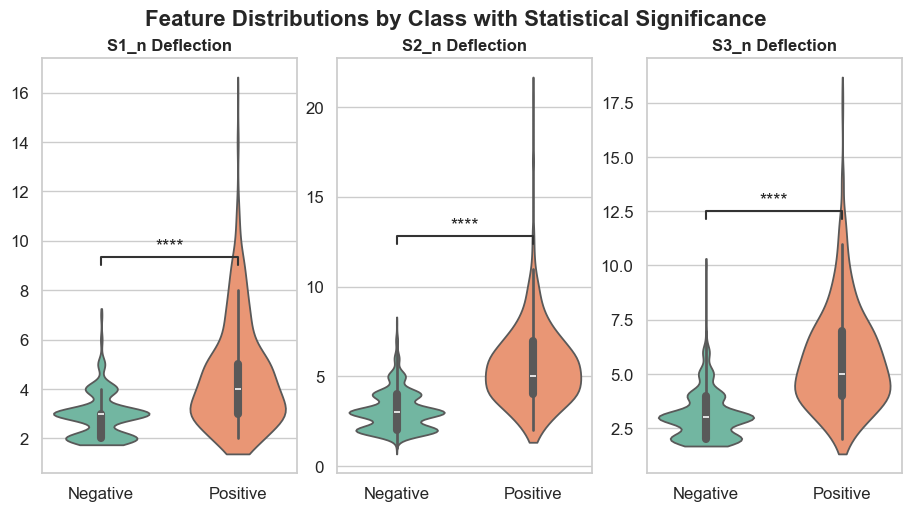

In [20]:
from statannotations.Annotator import Annotator
import seaborn as sns
# Setup
sns.set_theme(style="whitegrid", font_scale=1.1)

# Prepare the data
df_all = pd.DataFrame(mat_T_new, columns=Feature)  # Feature should be a list of feature names
df_all['Label'] = df["Label"]            # Binary class labels
y_min = df_all[Feature].min().min()
y_max = df_all[Feature].max().max()
# Plot setup
selected_features=Feature[Feature.index('S1_n Deflection'):Feature.index('S3_n Deflection')+1]
num_features = len(Feature)
cols = 3 # Number of plots per row
rows = -(-len(selected_features) // cols)  # Ceiling division

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 5), constrained_layout=True)

# Flatten axes for easy indexing
axes = axes.flatten()

# Plot each feature
for i, feature_name in enumerate(selected_features):
    ax = axes[i]
    
    # Prepare data for seaborn
    plot_data = df_all[[feature_name, 'Label']].copy()
    plot_data.columns = ['Value', 'Label']

    # Violin plot with box overlay
    sns.violinplot(data=plot_data, x='Label', y='Value', inner='box',
                palette='Set2',width=0.7, linewidth=1.3, cut=1, ax=ax)

    # Statistical annotation
    pairs = [("Negative","Positive")]
    annotator = Annotator(ax, pairs, data=plot_data, x='Label', y='Value')
    annotator.configure(test='Mann-Whitney', text_format='star', loc='inside', verbose=1)
    annotator.apply_and_annotate()

    # Titles and labels
    ax.set_title(f"{feature_name}", fontsize=12, weight='bold')
    ax.set_xlabel('')
    if i ==0:
        ax.set_ylabel('ms')
    ax.set_ylabel('')

# Turn off unused subplots if any
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle("Feature Distributions by Class with Statistical Significance", fontsize=16, weight='bold')
#plt.savefig(r"C:\Users\saman\Documents\GitHub\CIABIOMED\results\Feature analysis.svg",dpi=300)
plt.show()

In [35]:
sm=SMOTE(sampling_strategy="auto",random_state=42)
test,y=sm.fit_resample(matrix_T,POS_mask)
test.shape,y.shape,y[y].shape

((8614, 16), (8614,), (4307,))

[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............... (step 2 of 2) Processing svm, total=   0.3s
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............... (step 2 of 2) Processing svm, total=   0.3s
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............... (step 2 of 2) Processing svm, total=   0.3s
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............... (step 2 of 2) Processing svm, total=   0.3s
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............... (step 2 of 2) Processing svm, total=   0.3s
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............... (step 2 of 2) Processing svm, total=   0.3s
[Pipeline] ............ (step 1 of 2) Processing scaler, total=   0.0s
[Pipeline] ............... (step 2 of 2) Processing svm, total=   0.3s
[Pipel

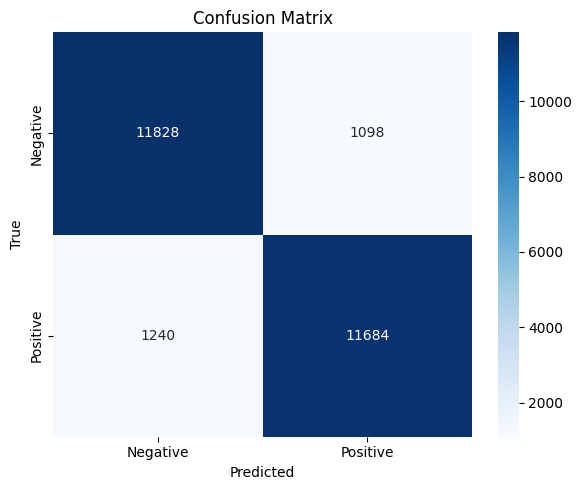

In [37]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

steps = [('scaler', StandardScaler()),
            #('oversample',SMOTE(sampling_strategy=0.5,random_state=42)),
            #('undersample', RandomUnderSampler(sampling_strategy=0.5, random_state=42)),
            #('pca',  PCA(2)),
            # ('scaler2', StandardScaler()), 
            ("svm", SVC(kernel="linear"))]
model = Pipeline(steps=steps,verbose=True)
# evaluate model
from sklearn.model_selection import StratifiedShuffleSplit
#cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=1)
cv=StratifiedShuffleSplit(n_splits=10, test_size=0.3, random_state=42)
scoring = {
'accuracy': 'accuracy',
'balanced_accuracy': 'balanced_accuracy',
'f1_weighted': 'f1_weighted',
'f1_macro': 'f1_macro'
}

# Storage for global results
y_true_all = []
y_pred_all = []
x_test_all=[]
matrix_T=test
POS_mask=y
for train_idx, test_idx in cv.split(matrix_T, POS_mask):
    X_train, y_train = matrix_T[train_idx], POS_mask[train_idx]
    X_test, y_test = matrix_T[test_idx], POS_mask[test_idx]

    # Train on training fold with full pipeline
    model.fit(X_train, y_train)
    sc=model.named_steps['scaler']
    #sc1=model.named_steps['scaler2']
    #pca = model.named_steps['pca']
    # Downsample only the test set
    #rus = RandomUnderSampler(sampling_strategy="auto", random_state=42)
    #X_test_bal, y_test_bal = rus.fit_resample(X_test, y_test)
    x=sc.transform(X_test)
    #x=pca.transform(x)
    #x=sc1.transform(x)
    x_test_all.extend(x)
    # Predict on balanced test set
    y_pred = model.predict(X_test)

    y_true_all.extend(y_test)
    y_pred_all.extend(y_pred)

# Final evaluation
print("Confusion Matrix (Balanced Test Sets):")
cm = confusion_matrix(y_true_all, y_pred_all)
print(cm)

print("\nClassification Report (Balanced Test Sets):")
from sklearn.metrics import classification_report, confusion_matrix
report = classification_report(y_true_all, y_pred_all, digits=3)
print(report)

# Per-class table
report_df = pd.DataFrame(classification_report(y_true_all, y_pred_all, output_dict=True)).T
print("\nPer-Class Performance Table:")
print(report_df)
import seaborn as sns
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


Training model: Logistic Regression

Classification Report for Logistic Regression:
              precision  recall  f1-score   support
False             0.983   0.915     0.948  17240.00
True              0.541   0.867     0.666   2000.00
accuracy          0.910   0.910     0.910      0.91
macro avg         0.762   0.891     0.807  19240.00
weighted avg      0.937   0.910     0.918  19240.00
Training model: Random Forest

Classification Report for Random Forest:
              precision  recall  f1-score    support
False             0.976   0.972     0.974  17240.000
True              0.768   0.796     0.782   2000.000
accuracy          0.954   0.954     0.954      0.954
macro avg         0.872   0.884     0.878  19240.000
weighted avg      0.955   0.954     0.954  19240.000
Training model: Gradient Boosting

Classification Report for Gradient Boosting:
              precision  recall  f1-score    support
False             0.977   0.970     0.974  17240.000
True              0.756   0.

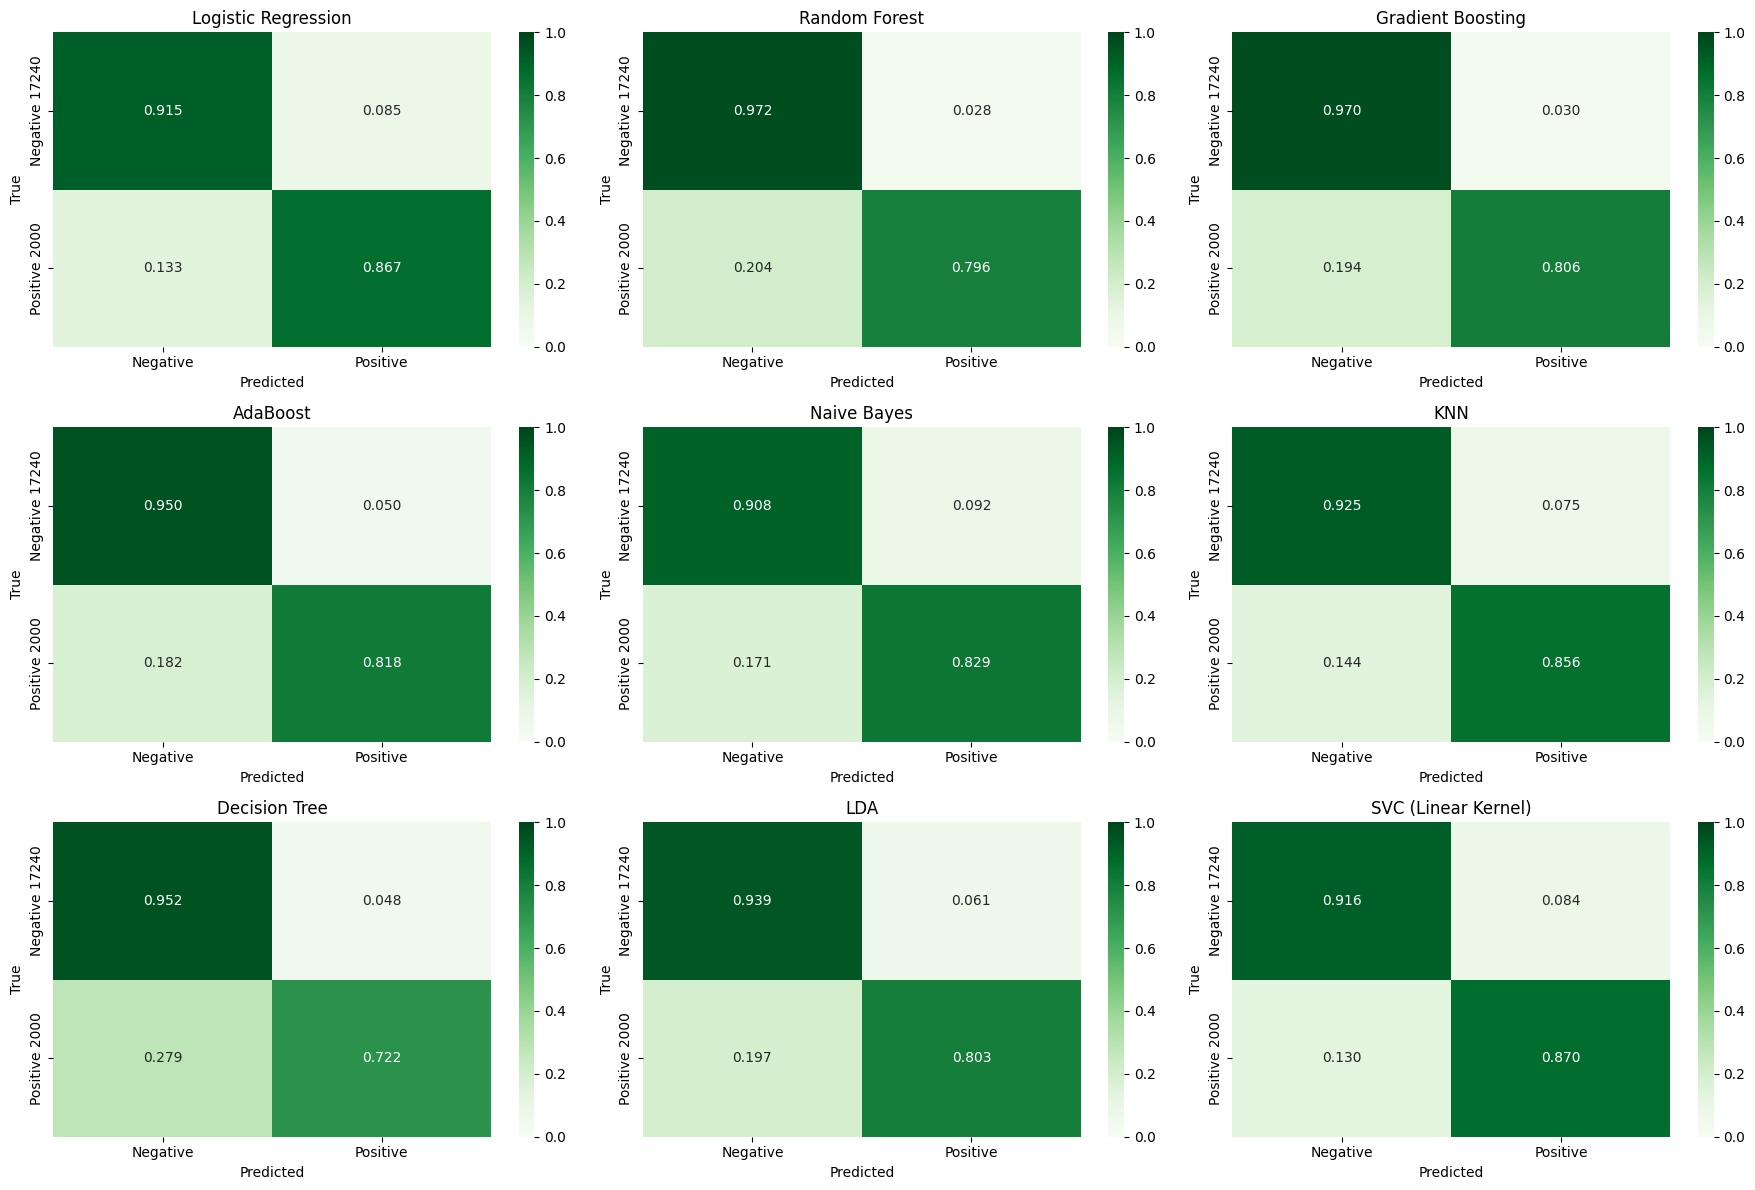

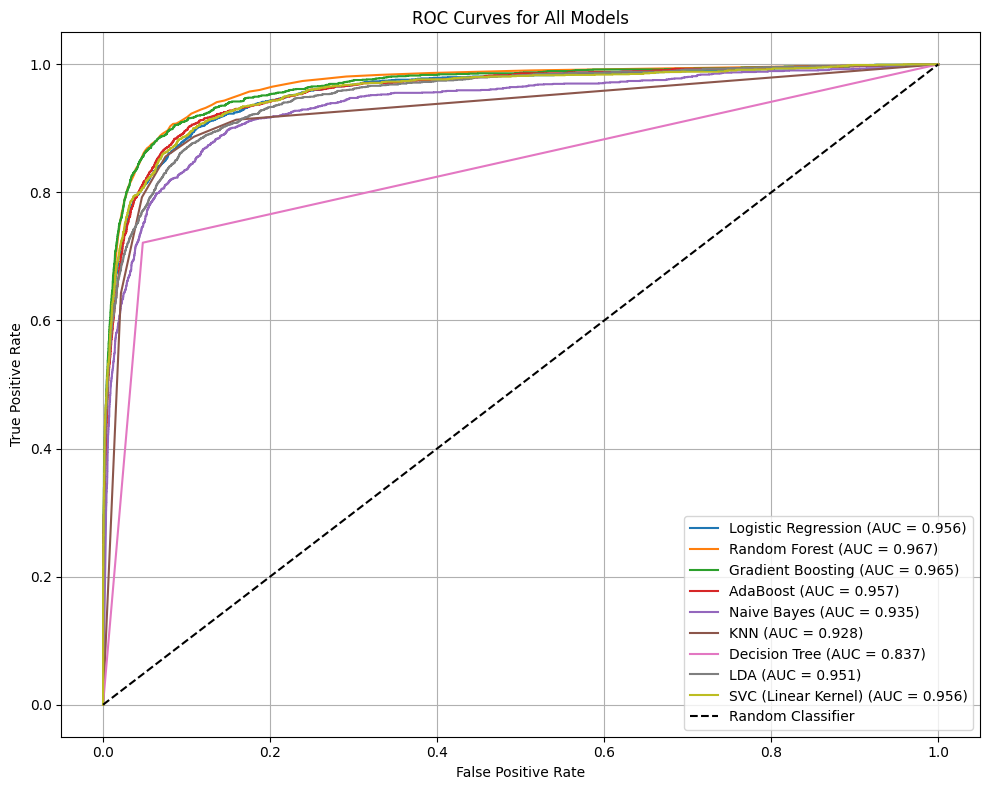



Summary of All Models:
                 Model  Accuracy  Accuracy_balanced  F1-Weighted  F1-Macro  \
0        Random Forest     0.954              0.884        0.954     0.878   
1    Gradient Boosting     0.953              0.888        0.953     0.877   
2             AdaBoost     0.936              0.884        0.939     0.845   
3        Decision Tree     0.928              0.837        0.930     0.818   
4                  LDA     0.925              0.871        0.929     0.823   
5                  KNN     0.918              0.891        0.925     0.819   
6  SVC (Linear Kernel)     0.911              0.893        0.920     0.810   
7  Logistic Regression     0.910              0.891        0.918     0.807   
8          Naive Bayes     0.900              0.869        0.910     0.787   

   Recall (Class 1: Healthy)  Precission macro (Class 1)  Precision (Class 1)  \
0                      0.972                       0.827                0.976   
1                      0.970    

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, roc_auc_score,
    balanced_accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Define all models to evaluate
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "LDA": LDA(),
    "SVC (Linear Kernel)": SVC(kernel="linear", probability=True)
}

# Cross-validation
cv = StratifiedShuffleSplit(n_splits=10, test_size=0.4, random_state=42)

# Define input data (ensure matrix_T and POS_mask are defined before this script runs)
# matrix_T = ...
# POS_mask = ...

summary_rows = []
roc_data = []

# Set up subplots for confusion matrices
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (name, clf) in enumerate(models.items()):
    print(f"Training model: {name}")
    
    pipeline = Pipeline([
        ("SM", SMOTE(sampling_strategy="auto", random_state=42)),
        ('scaler', StandardScaler()),
        (name, clf)
    ])

    y_true_all = []
    y_pred_all = []
    y_proba_all = []

    for train_idx, test_idx in cv.split(matrix_T, POS_mask):
        X_train, y_train = matrix_T[train_idx], POS_mask[train_idx]
        X_test, y_test = matrix_T[test_idx], POS_mask[test_idx]

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        y_proba = pipeline.predict_proba(X_test)[:, 1]  # probability of class 1

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)
        y_proba_all.extend(y_proba)

    # Evaluation
    cm = confusion_matrix(y_true_all, y_pred_all)
    report = classification_report(y_true_all, y_pred_all, output_dict=True)
    cm_recall = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    precision_macro = precision_score(y_true_all, y_pred_all, average='macro')
    recall_macro = recall_score(y_true_all, y_pred_all, average='macro')
    f1_macro = f1_score(y_true_all, y_pred_all, average='macro')
    balanced_acc = balanced_accuracy_score(y_true_all, y_pred_all)

    # ROC and AUC
    fpr, tpr, _ = roc_curve(y_true_all, y_proba_all)
    auc = roc_auc_score(y_true_all, y_proba_all)
    roc_data.append({
        "model": name,
        "fpr": fpr,
        "tpr": tpr,
        "auc": auc
    })

    # Summary
    summary_rows.append({
        "Model": name,
        "Accuracy": report["accuracy"],
        "Accuracy_balanced": balanced_acc,
        "F1-Weighted": report["weighted avg"]["f1-score"],
        "F1-Macro": f1_macro,
        "Recall (Class 1: Healthy)": report["False"]["recall"],
        "Precission macro (Class 1)": report["False"]["recall"]/(report["False"]["recall"]+(1-report["True"]["recall"])),
        "Precision (Class 1)": report["False"]["precision"],
        "Recall (Class 2: Abnormal)": report["True"]["recall"],
        "Precision macro (Class 2)": report["True"]["recall"]/(report["True"]["recall"]+(1-report["False"]["recall"])),
        "Precision (Class 2)": report["True"]["precision"],
        "AUC": auc
    })

    # Plot confusion matrix
    sns.heatmap(cm_recall, annot=True, fmt='.3f', cmap='Greens',
                xticklabels=['Negative', 'Positive'],
                yticklabels=[
                    f'Negative {cm[0].sum()}',
                    f'Positive {cm[1].sum()}'
                ],
                vmin=0, vmax=1, ax=axes[i])
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')

    print(f"\nClassification Report for {name}:")
    print(pd.DataFrame(report).T.round(3))

plt.tight_layout()
ML_save_path = os.path.join(base_dir, "ML_confusion_matrices.svg")
plt.savefig(ML_save_path, format='svg', dpi=300)
plt.show()

# ROC Curve Plot
plt.figure(figsize=(10, 8))
for data in roc_data:
    plt.plot(data["fpr"], data["tpr"], label=f'{data["model"]} (AUC = {data["auc"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
ROC_save_path = os.path.join(base_dir, "ML_ROC_curves.svg")
plt.savefig(ROC_save_path, dpi=300)
plt.show()

# Summary Table
summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(by="F1-Weighted", ascending=False).reset_index(drop=True)
print("\n\nSummary of All Models:")
print(summary_df.round(3))

#with pd.ExcelWriter("ML_model_performance.xlsx") as writer:
#    summary_df.round(3).to_excel(writer, sheet_name="ML_performance")


In [18]:
import numpy as np

# unique case names
unique_cases = np.unique(case_ids)

# shuffle once for reproducibility
rng = np.random.default_rng(42)
shuffled_cases = rng.permutation(unique_cases)

# make folds of 2 test cases each
group_folds = []
for i in range(0, len(shuffled_cases), 2):
    test_cases = shuffled_cases[i:i+2]
    if len(test_cases) < 2:
        break   # skip last single case if odd number

    test_mask = np.isin(case_ids, test_cases)
    train_idx = np.where(~test_mask)[0]
    test_idx = np.where(test_mask)[0]

    group_folds.append((train_idx, test_idx, test_cases))

print("Number of folds:", len(group_folds))
for i, (_, _, test_cases) in enumerate(group_folds, 1):
    print(f"Fold {i}: test={list(test_cases)}")

Number of folds: 12
Fold 1: test=[np.str_('P022'), np.str_('P021')]
Fold 2: test=[np.str_('P024'), np.str_('P025')]
Fold 3: test=[np.str_('P014'), np.str_('P010')]
Fold 4: test=[np.str_('P023'), np.str_('P030')]
Fold 5: test=[np.str_('P009'), np.str_('P016')]
Fold 6: test=[np.str_('P006'), np.str_('P001')]
Fold 7: test=[np.str_('P026'), np.str_('P018')]
Fold 8: test=[np.str_('P008'), np.str_('P017')]
Fold 9: test=[np.str_('P020'), np.str_('P028')]
Fold 10: test=[np.str_('P005'), np.str_('P007')]
Fold 11: test=[np.str_('P027'), np.str_('P003')]
Fold 12: test=[np.str_('P019'), np.str_('P012')]



Training model: Logistic Regression
Fold 001 | test cases = [np.str_('P022'), np.str_('P021')] | train cases = 22 | test samples = 393
Fold 002 | test cases = [np.str_('P024'), np.str_('P025')] | train cases = 22 | test samples = 277
Fold 003 | test cases = [np.str_('P014'), np.str_('P010')] | train cases = 22 | test samples = 433
Fold 004 | test cases = [np.str_('P023'), np.str_('P030')] | train cases = 22 | test samples = 424
Fold 005 | test cases = [np.str_('P009'), np.str_('P016')] | train cases = 22 | test samples = 371
Fold 006 | test cases = [np.str_('P006'), np.str_('P001')] | train cases = 22 | test samples = 405
Fold 007 | test cases = [np.str_('P026'), np.str_('P018')] | train cases = 22 | test samples = 370
Fold 008 | test cases = [np.str_('P008'), np.str_('P017')] | train cases = 22 | test samples = 551
Fold 009 | test cases = [np.str_('P020'), np.str_('P028')] | train cases = 22 | test samples = 441
Fold 010 | test cases = [np.str_('P005'), np.str_('P007')] | train cases

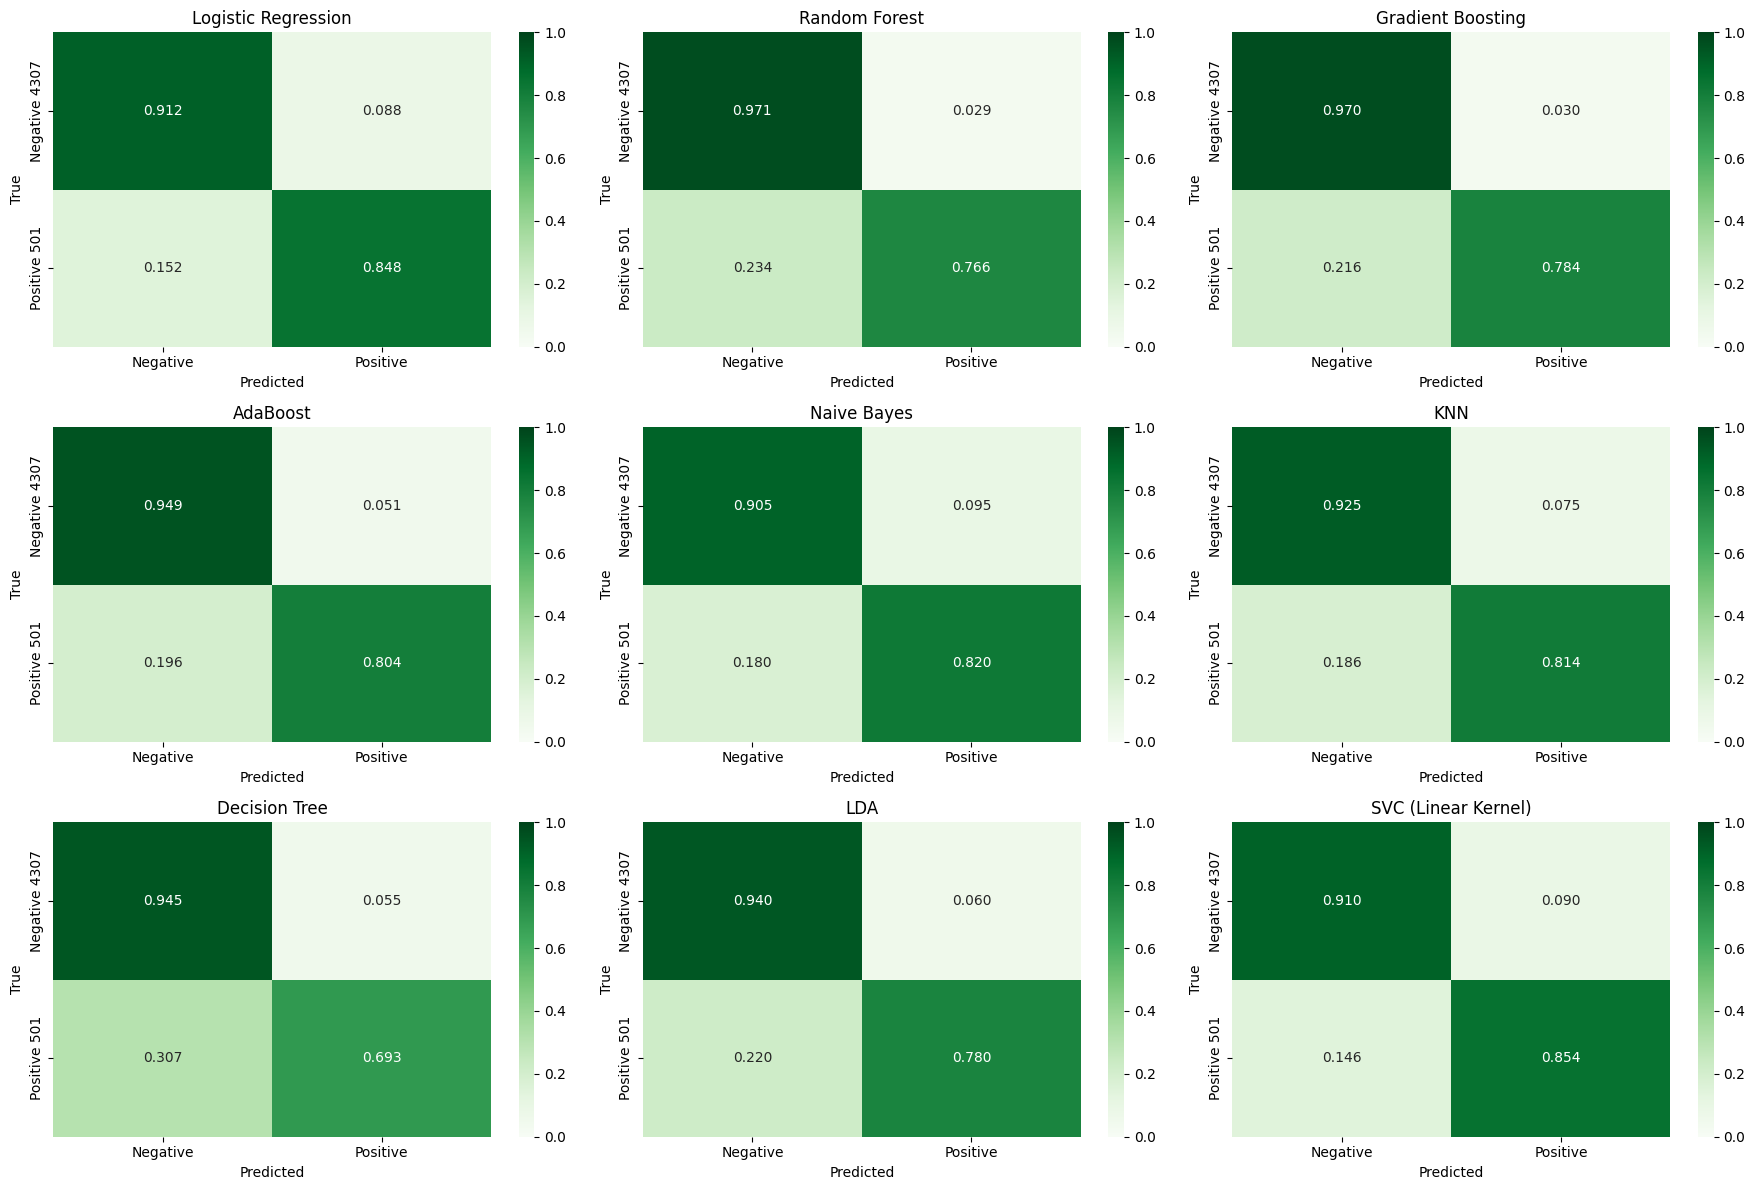

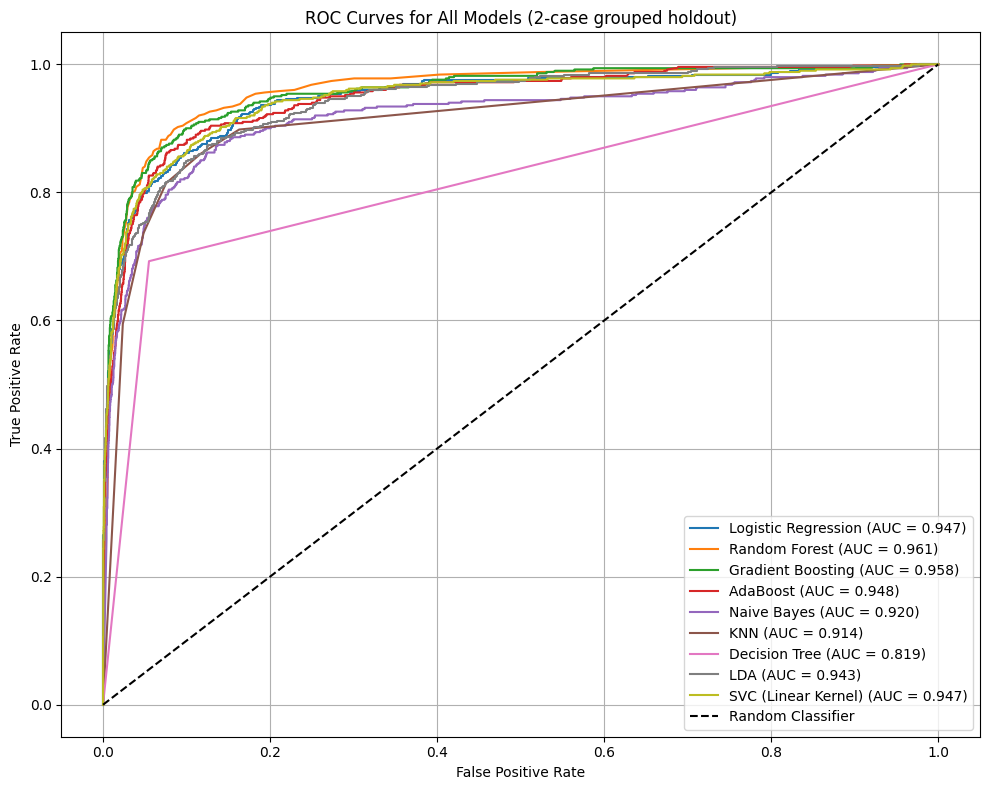



Summary of All Models:
                 Model  Accuracy  Accuracy_balanced  F1-Weighted  F1-Macro  \
0    Gradient Boosting     0.951              0.877        0.951     0.870   
1        Random Forest     0.950              0.869        0.950     0.867   
2             AdaBoost     0.934              0.877        0.937     0.841   
3                  LDA     0.923              0.860        0.928     0.818   
4        Decision Tree     0.919              0.819        0.921     0.797   
5                  KNN     0.913              0.869        0.920     0.806   
6  Logistic Regression     0.905              0.880        0.914     0.798   
7  SVC (Linear Kernel)     0.904              0.882        0.914     0.798   
8          Naive Bayes     0.896              0.863        0.907     0.781   

   Recall (Negative)  Precision (Negative)  Recall (Positive)  \
0              0.970                 0.975              0.784   
1              0.971                 0.973              0.766   

In [19]:
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, roc_auc_score,
    balanced_accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.svm import SVC
from sklearn.model_selection import LeavePGroupsOut
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# =========================================================
# Models
# =========================================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "LDA": LDA(),
    "SVC (Linear Kernel)": SVC(kernel="linear", probability=True, random_state=42)
}

# =========================================================
# 2-case rotating holdout
# =========================================================


summary_rows = []
roc_data = []

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (name, clf) in enumerate(models.items()):
    print(f"\n{'='*80}")
    print(f"Training model: {name}")
    print(f"{'='*80}")

    pipeline = Pipeline([
        ("smote", SMOTE(sampling_strategy="auto", random_state=42)),
        ("scaler", StandardScaler()),
        ("model", clf)
    ])

    y_true_all = []
    y_pred_all = []
    y_proba_all = []

    fold_info = []

    for fold, (train_idx, test_idx, test_cases) in enumerate(group_folds, start=1):
        X_train, y_train = matrix_T[train_idx], POS_mask[train_idx]
        X_test, y_test = matrix_T[test_idx], POS_mask[test_idx]

        train_cases = np.unique(case_ids[train_idx])

        print(f"Fold {fold:03d} | test cases = {list(test_cases)} | "
              f"train cases = {len(train_cases)} | test samples = {len(test_idx)}")

        # Fit only on training cases
        pipeline.fit(X_train, y_train)

        # Predict
        y_pred = pipeline.predict(X_test)

        # Some classifiers may fail predict_proba in rare situations
        if hasattr(pipeline, "predict_proba"):
            y_proba = pipeline.predict_proba(X_test)[:, 1]
        else:
            # fallback if needed
            y_proba = y_pred.astype(float)

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)
        y_proba_all.extend(y_proba)

        fold_info.append({
            "fold": fold,
            "test_cases": ",".join(test_cases),
            "n_test_samples": len(test_idx),
            "n_test_pos": int(np.sum(y_test)),
            "n_test_neg": int(len(y_test) - np.sum(y_test))
        })

    # -----------------------------------------------------
    # Evaluation
    # -----------------------------------------------------
    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)
    y_proba_all = np.array(y_proba_all)

    cm = confusion_matrix(y_true_all, y_pred_all)
    report = classification_report(y_true_all, y_pred_all, output_dict=True, zero_division=0)
    cm_recall = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    precision_macro = precision_score(y_true_all, y_pred_all, average='macro', zero_division=0)
    recall_macro = recall_score(y_true_all, y_pred_all, average='macro', zero_division=0)
    f1_macro = f1_score(y_true_all, y_pred_all, average='macro', zero_division=0)
    balanced_acc = balanced_accuracy_score(y_true_all, y_pred_all)

    fpr, tpr, _ = roc_curve(y_true_all, y_proba_all)
    auc = roc_auc_score(y_true_all, y_proba_all)

    roc_data.append({
        "model": name,
        "fpr": fpr,
        "tpr": tpr,
        "auc": auc
    })

    # safer access for boolean labels in report dict
    # classification_report keys become 'False'/'True' if y is bool
    neg_key = "False"
    pos_key = "True"

    summary_rows.append({
        "Model": name,
        "Accuracy": report["accuracy"],
        "Accuracy_balanced": balanced_acc,
        "F1-Weighted": report["weighted avg"]["f1-score"],
        "F1-Macro": f1_macro,
        "Recall (Negative)": report[neg_key]["recall"],
        "Precision (Negative)": report[neg_key]["precision"],
        "Recall (Positive)": report[pos_key]["recall"],
        "Precision (Positive)": report[pos_key]["precision"],
        "Precision-Macro": precision_macro,
        "Recall-Macro": recall_macro,
        "AUC": auc
    })

    sns.heatmap(
        cm_recall,
        annot=True,
        fmt=".3f",
        cmap="Greens",
        xticklabels=["Negative", "Positive"],
        yticklabels=[f"Negative {cm[0].sum()}", f"Positive {cm[1].sum()}"],
        vmin=0,
        vmax=1,
        ax=axes[i]
    )
    axes[i].set_title(name)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("True")

    print(f"\nClassification Report for {name}:")
    print(pd.DataFrame(report).T.round(3))

plt.tight_layout()
ML_save_path = os.path.join(base_dir, "ML_conf_2case_grouped.svg")
plt.savefig(ML_save_path, format='svg', dpi=300)
plt.show()

# =========================================================
# ROC curves
# =========================================================
plt.figure(figsize=(10, 8))
for data in roc_data:
    plt.plot(data["fpr"], data["tpr"], label=f'{data["model"]} (AUC = {data["auc"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models (2-case grouped holdout)')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================================
# Summary table
# =========================================================
summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(by="F1-Weighted", ascending=False).reset_index(drop=True)

print("\n\nSummary of All Models:")
print(summary_df.round(3))

### Export trained ML models

This exports **all** classifiers compared above:

- **`models_full`**: each model retrained on 100% of `matrix_T` / `POS_mask` for deployment
- **`models_cv_folds`**: the fitted pipeline from each grouped holdout fold (the models actually used during CV evaluation)
- **`cv_summary`**: metrics from the comparison table so you can choose models elsewhere

During CV, fold models are trained only on the training cases of that fold and are discarded after evaluation unless exported here. For production use, prefer `models_full`; use fold models if you want fold-specific or ensemble behavior.

In [20]:
from ml_model_io import save_sklearn_model_suite, load_sklearn_model_suite, list_models, predict_with_models
from ml_model_io import clone_unfitted_estimator

feature_names = Feature[:matrix_T.shape[1]]
models_full = {}
models_cv_folds = {}

for name, clf in models.items():
    print(f"Exporting: {name}")

    # 1) Full-data model for deployment
    full_pipeline = Pipeline([
        ("smote", SMOTE(sampling_strategy="auto", random_state=42)),
        ("scaler", StandardScaler()),
        ("model", clone_unfitted_estimator(clf)),
    ])
    full_pipeline.fit(matrix_T, POS_mask)
    models_full[name] = full_pipeline

    # 2) CV fold models from the grouped holdout used above
    fold_entries = []
    for fold, (train_idx, test_idx, test_cases) in enumerate(group_folds, start=1):
        X_train, y_train = matrix_T[train_idx], POS_mask[train_idx]

        fold_pipeline = Pipeline([
            ("smote", SMOTE(sampling_strategy="auto", random_state=42)),
            ("scaler", StandardScaler()),
            ("model", clone_unfitted_estimator(clf)),
        ])
        fold_pipeline.fit(X_train, y_train)

        fold_entries.append({
            "fold": fold,
            "test_cases": list(test_cases),
            "n_train": int(len(train_idx)),
            "n_test": int(len(test_idx)),
            "pipeline": fold_pipeline,
        })

    models_cv_folds[name] = fold_entries

ml_export_path = os.path.join(base_dir, "persuade_esc_classifiers.joblib")
save_sklearn_model_suite(
    models_full=models_full,
    feature_names=feature_names,
    export_path=ml_export_path,
    cv_summary=summary_df.to_dict(orient="records"),
    models_cv_folds=models_cv_folds,
    metadata={
        "n_samples": int(matrix_T.shape[0]),
        "n_features": int(matrix_T.shape[1]),
        "cv_type": "2-case grouped holdout",
        "n_folds": len(group_folds),
    },
)
print(f"Exported all ML models to: {ml_export_path}")

loaded = load_sklearn_model_suite(ml_export_path)
print("Available models:", list_models(loaded))
print("CV summary (top 3 by F1-Weighted):")
print(pd.DataFrame(loaded["cv_summary"]).head(3)[["Model", "F1-Weighted", "AUC"]])

# Example: use one model
one_model = loaded["cv_summary"][0]["Model"]
one_pred = predict_with_models(loaded, [one_model], matrix_T[:5], source="full")
print(f"Single-model check ({one_model}):", one_pred["predictions"])

# Example: ensemble top 2 models by F1-Weighted
top_models = pd.DataFrame(loaded["cv_summary"]).head(2)["Model"].tolist()
ensemble_pred = predict_with_models(
    loaded,
    top_models,
    matrix_T[:5],
    source="full",
    strategy="average_proba",
)
print(f"Ensemble check ({', '.join(top_models)}):", ensemble_pred["predictions"])
print(f"Ensemble probabilities:", ensemble_pred["positive_probabilities"].round(3))


Exporting: Logistic Regression
Exporting: Random Forest
Exporting: Gradient Boosting
Exporting: AdaBoost
Exporting: Naive Bayes
Exporting: KNN
Exporting: Decision Tree
Exporting: LDA
Exporting: SVC (Linear Kernel)
Exported all ML models to: D:/INIBICA/AnnotatedFeatures\persuade_esc_classifiers.joblib
Available models: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'AdaBoost', 'Naive Bayes', 'KNN', 'Decision Tree', 'LDA', 'SVC (Linear Kernel)']
CV summary (top 3 by F1-Weighted):
               Model  F1-Weighted       AUC
0  Gradient Boosting     0.951153  0.957531
1      Random Forest     0.950214  0.960957
2           AdaBoost     0.937327  0.947827
Single-model check (Gradient Boosting): [False False False False  True]
Ensemble check (Gradient Boosting, Random Forest): [False False False False  True]
Ensemble probabilities: [0.004 0.015 0.005 0.077 0.922]


# AI model for automatic annotation

In [46]:

case = json_data["P001"]

print("type(case):", type(case))
print("len p_numbers:", len(case.p_numbers))
print("len labels:", len(case.labels))
print("len SR:", len(case.SR))
print("len First:", len(case.First))
print("len Second:", len(case.Second))
print("len Third:", len(case.Third))
print("len Stim_refs:", len(case.Stim_refs))
print("type SR_ref:", type(case.SR_ref), "value:", case.SR_ref)

for name in ["SR", "First", "Second", "Third", "Sinus_dur", "First_dur", "Second_dur", "Third_dur", "Stim_refs"]:
    val = getattr(case, name, None)
    print("\n---", name, "---")
    print("type:", type(val))
    if hasattr(val, "__len__"):
        print("len:", len(val))
        print("first 10:", val[:10])
    else:
        print("value:", val)

type(case): <class '__main__.LAT_points'>
len p_numbers: 258
len labels: 258
len SR: 258
len First: 258
len Second: 258
len Third: 258
len Stim_refs: 258
type SR_ref: <class 'list'> value: [490, 490, 490, 490, 490, 490, 490, 490, 490, 490, 491, 491, 491, 491, 491, 491, 491, 491, 491, 491, 495, 495, 495, 495, 495, 495, 495, 495, 495, 495, 490, 490, 490, 490, 490, 490, 490, 495, 495, 495, 495, 495, 495, 495, 495, 495, 495, 598, 598, 598, 598, 598, 598, 598, 598, 598, 598, 572, 572, 572, 572, 572, 572, 572, 499, 499, 499, 499, 499, 499, 499, 499, 606, 606, 606, 606, 606, 606, 606, 606, 486, 486, 486, 486, 486, 486, 486, 497, 497, 497, 497, 497, 497, 497, 497, 497, 497, 616, 616, 616, 616, 616, 616, 616, 616, 616, 616, 503, 503, 503, 503, 503, 503, 503, 503, 503, 503, 623, 623, 623, 623, 623, 623, 623, 615, 615, 615, 615, 615, 615, 615, 615, 615, 474, 474, 474, 474, 474, 474, 474, 474, 474, 474, 511, 511, 511, 511, 511, 511, 511, 511, 511, 511, 505, 505, 505, 505, 505, 505, 505, 505, 505, 

In [47]:
case = json_data["P001"]
i = 0

print("row:", i)
print("p_number:", case.p_numbers[i])
print("label:", case.labels[i])

print("SR:", case.SR[i])
print("SR_ref:", case.SR_ref)

print("First:", case.First[i])
print("Second:", case.Second[i])
print("Third:", case.Third[i])

print("Stim_ref:", case.Stim_refs[i])

print("Sinus_dur:", case.Sinus_dur[i] if i < len(case.Sinus_dur) else None)
print("First_dur:", case.First_dur[i] if i < len(case.First_dur) else None)
print("Second_dur:", case.Second_dur[i] if i < len(case.Second_dur) else None)
print("Third_dur:", case.Third_dur[i] if i < len(case.Third_dur) else None)

row: 0
p_number: 407
label: NEG
SR: -126
SR_ref: [490, 490, 490, 490, 490, 490, 490, 490, 490, 490, 491, 491, 491, 491, 491, 491, 491, 491, 491, 491, 495, 495, 495, 495, 495, 495, 495, 495, 495, 495, 490, 490, 490, 490, 490, 490, 490, 495, 495, 495, 495, 495, 495, 495, 495, 495, 495, 598, 598, 598, 598, 598, 598, 598, 598, 598, 598, 572, 572, 572, 572, 572, 572, 572, 499, 499, 499, 499, 499, 499, 499, 499, 606, 606, 606, 606, 606, 606, 606, 606, 486, 486, 486, 486, 486, 486, 486, 497, 497, 497, 497, 497, 497, 497, 497, 497, 497, 616, 616, 616, 616, 616, 616, 616, 616, 616, 616, 503, 503, 503, 503, 503, 503, 503, 503, 503, 503, 623, 623, 623, 623, 623, 623, 623, 615, 615, 615, 615, 615, 615, 615, 615, 615, 474, 474, 474, 474, 474, 474, 474, 474, 474, 474, 511, 511, 511, 511, 511, 511, 511, 511, 511, 511, 505, 505, 505, 505, 505, 505, 505, 505, 505, 505, 507, 507, 507, 507, 507, 507, 502, 502, 502, 502, 502, 502, 502, 502, 502, 502, 509, 509, 509, 509, 509, 509, 509, 509, 509, 509, 501, 

In [10]:
records = build_event_records(json_data, sig_data)
print("records:", len(records))
print(records[:10])

NameError: name 'build_event_records' is not defined

In [48]:
import random
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader


# =========================================================
# Config
# =========================================================

EVENT_NAMES = ["SR", "First", "Second", "Third"]
EVENT_TO_ID = {name: i for i, name in enumerate(EVENT_NAMES)}


# =========================================================
# Basic helpers
# =========================================================

def to_int_or_none(v):
    try:
        if v is None:
            return None
        if isinstance(v, str) and not v.strip():
            return None
        f = float(v)
        if np.isnan(f):
            return None
        return int(round(f))
    except Exception:
        return None


def normalize_point_id(pnum):
    try:
        return str(int(round(float(pnum))))
    except Exception:
        return str(pnum).strip()


def safe_to_numpy(x):
    if isinstance(x, pd.Series):
        arr = x.to_numpy(dtype=np.float32)
    else:
        arr = np.asarray(x, dtype=np.float32)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return arr.astype(np.float32)


def normalize_1d(x: np.ndarray) -> np.ndarray:
    x = x.astype(np.float32).copy()
    mu = x.mean()
    std = x.std()
    if std < 1e-8:
        x = x - mu
    else:
        x = (x - mu) / std
    return x.astype(np.float32)


def augment_signal_1d(
    x: np.ndarray,
    noise_std_ratio: float = 0.01,
    amp_scale_range: Tuple[float, float] = (0.9, 1.1),
    baseline_shift_std: float = 0.02,
) -> np.ndarray:
    x = x.copy()

    scale = np.random.uniform(*amp_scale_range)
    x *= scale
    x += np.random.normal(0.0, baseline_shift_std)

    s = float(np.std(x))
    if s < 1e-8:
        s = 1.0

    noise = np.random.normal(0.0, noise_std_ratio * s, size=x.shape).astype(np.float32)
    x += noise
    return x.astype(np.float32)


# =========================================================
# Annotation resolving
# =========================================================

def resolve_start_end_indices(case_obj, row_idx: int, event_name: str):
    """
    SR:
        start = SR_ref[row_idx] + SR[row_idx]
        end   = start + Sinus_dur[row_idx]

    First:
        start = Stim_refs[row_idx][0] + First[row_idx]
        end   = start + First_dur[row_idx]

    Second:
        start = Stim_refs[row_idx][1] + Second[row_idx]
        end   = start + Second_dur[row_idx]

    Third:
        start = Stim_refs[row_idx][2] + Third[row_idx]
        end   = start + Third_dur[row_idx]
    """

    if event_name == "SR":
        sr = getattr(case_obj, "SR", None)
        sr_ref = getattr(case_obj, "SR_ref", None)
        sr_dur = getattr(case_obj, "Sinus_dur", None)

        if sr is None or sr_ref is None or sr_dur is None:
            return None
        if row_idx >= len(sr) or row_idx >= len(sr_ref) or row_idx >= len(sr_dur):
            return None

        rel = to_int_or_none(sr[row_idx])
        ref = to_int_or_none(sr_ref[row_idx])
        dur = to_int_or_none(sr_dur[row_idx])

        if rel is None or ref is None or dur is None or dur <= 0:
            return None

        start = ref + rel
        end = start + dur
        return start, end

    stim_refs = getattr(case_obj, "Stim_refs", None)
    if stim_refs is None or row_idx >= len(stim_refs):
        return None

    stim_row = stim_refs[row_idx]
    if not isinstance(stim_row, (list, tuple)) or len(stim_row) < 3:
        return None

    if event_name == "First":
        event_list = getattr(case_obj, "First", None)
        dur_list = getattr(case_obj, "First_dur", None)
        ref = to_int_or_none(stim_row[0])

    elif event_name == "Second":
        event_list = getattr(case_obj, "Second", None)
        dur_list = getattr(case_obj, "Second_dur", None)
        ref = to_int_or_none(stim_row[1])

    elif event_name == "Third":
        event_list = getattr(case_obj, "Third", None)
        dur_list = getattr(case_obj, "Third_dur", None)
        ref = to_int_or_none(stim_row[2])

    else:
        return None

    if event_list is None or dur_list is None:
        return None
    if row_idx >= len(event_list) or row_idx >= len(dur_list):
        return None

    rel = to_int_or_none(event_list[row_idx])
    dur = to_int_or_none(dur_list[row_idx])

    if rel is None or ref is None or dur is None or dur <= 0:
        return None

    start = ref + rel
    end = start + dur
    return start, end


def build_event_records(json_data, sig_data):
    records = []

    for case_id, case_obj in json_data.items():
        if case_id not in sig_data:
            continue

        p_numbers = getattr(case_obj, "p_numbers", None)
        labels = getattr(case_obj, "labels", None)

        if p_numbers is None:
            continue

        for row_idx, pnum in enumerate(p_numbers):
            point_id = normalize_point_id(pnum)

            if point_id not in sig_data[case_id]:
                continue

            sig_entry = sig_data[case_id][point_id]
            if "biloc" not in sig_entry:
                continue

            sig_len = len(sig_entry["biloc"])

            for event_name in EVENT_NAMES:
                se = resolve_start_end_indices(case_obj, row_idx, event_name)
                if se is None:
                    continue

                start_idx, end_idx = se

                if not (0 <= start_idx < sig_len):
                    continue
                if not (0 <= end_idx < sig_len):
                    continue
                if end_idx <= start_idx:
                    continue

                records.append({
                    "case_id": case_id,
                    "row_idx": row_idx,
                    "point_id": point_id,
                    "event_name": event_name,
                    "event_id": EVENT_TO_ID[event_name],
                    "start_idx": int(start_idx),
                    "end_idx": int(end_idx),
                    "label": labels[row_idx] if labels is not None and row_idx < len(labels) else None,
                })

    return records


# =========================================================
# Chunk extraction
# =========================================================

def extract_chunk_around_region_1d(
    signal_1d: np.ndarray,
    start_idx: int,
    end_idx: int,
    window_size: int = 400,
    max_offset: int = 150,
) -> Tuple[np.ndarray, int, int]:
    T = signal_1d.shape[0]

    if T < window_size:
        pad_total = window_size - T
        pad_left = pad_total // 2
        pad_right = pad_total - pad_left
        signal_1d = np.pad(signal_1d, (pad_left, pad_right), mode="constant")
        T = signal_1d.shape[0]
        start_idx += pad_left
        end_idx += pad_left

    center = (start_idx + end_idx) // 2
    half = window_size // 2
    offset = np.random.randint(-max_offset, max_offset + 1)

    chunk_start = center - half + offset
    chunk_end = chunk_start + window_size

    if chunk_start < 0:
        chunk_start = 0
        chunk_end = window_size

    if chunk_end > T:
        chunk_end = T
        chunk_start = T - window_size

    chunk = signal_1d[chunk_start:chunk_end]
    local_start = start_idx - chunk_start
    local_end = end_idx - chunk_start

    local_start = max(0, min(window_size - 1, local_start))
    local_end = max(0, min(window_size - 1, local_end))

    return chunk.astype(np.float32), int(local_start), int(local_end)


# =========================================================
# Targets
# =========================================================

def stable_sigmoid(x: np.ndarray) -> np.ndarray:
    x = x.astype(np.float32)
    out = np.empty_like(x, dtype=np.float32)

    pos = x >= 0
    neg = ~pos

    out[pos] = 1.0 / (1.0 + np.exp(-x[pos]))
    ex = np.exp(x[neg])
    out[neg] = ex / (1.0 + ex)

    return out


def soft_interval_target(length: int, start: int, end: int, sharpness: float = 1.5) -> np.ndarray:
    """
    Smooth active region:
      ~0 before start
      ~1 between start and end
      ~0 after end
    """
    t = np.arange(length, dtype=np.float32)
    left = stable_sigmoid(sharpness * (t - start))
    right = stable_sigmoid(sharpness * (end - t))
    y = left * right
    return y.astype(np.float32)


def gaussian_peak_target(length: int, center: int, sigma: float = 3.0) -> np.ndarray:
    t = np.arange(length, dtype=np.float32)
    y = np.exp(-0.5 * ((t - float(center)) / float(sigma)) ** 2)
    y /= max(1e-8, y.max())
    return y.astype(np.float32)


# =========================================================
# Time-frequency map
# =========================================================

def compute_tf_map(
    signal_1d: np.ndarray,
    n_freq_bins: int = 20,
    out_time_bins: int = 400,
    sr: int = 1000,
    n_fft: int = 64,
    hop_length: int = 1,
) -> np.ndarray:
    x = signal_1d.astype(np.float32)
    spec = None

    try:
        import librosa

        freqs, times, D = librosa.reassigned_spectrogram(
            y=x,
            sr=sr,
            n_fft=n_fft,
            hop_length=hop_length,
            win_length=n_fft,
            center=True,
            reassign_frequencies=True,
            reassign_times=True,
            fill_nan=True,
        )
        spec = np.abs(D).astype(np.float32)

    except Exception:
        from scipy.signal import stft

        _, _, Zxx = stft(
            x,
            fs=sr,
            nperseg=n_fft,
            noverlap=n_fft - hop_length,
            nfft=n_fft,
            boundary=None,
            padded=False,
        )
        spec = np.abs(Zxx).astype(np.float32)

    if spec.ndim != 2:
        raise ValueError(f"Unexpected spectrogram shape: {spec.shape}")

    if spec.shape[0] >= n_freq_bins:
        spec = spec[:n_freq_bins, :]
    else:
        pad_f = n_freq_bins - spec.shape[0]
        spec = np.pad(spec, ((0, pad_f), (0, 0)), mode="constant")

    if spec.shape[1] != out_time_bins:
        old_t = np.linspace(0.0, 1.0, spec.shape[1], dtype=np.float32)
        new_t = np.linspace(0.0, 1.0, out_time_bins, dtype=np.float32)
        resized = np.empty((spec.shape[0], out_time_bins), dtype=np.float32)
        for f in range(spec.shape[0]):
            resized[f] = np.interp(new_t, old_t, spec[f])
        spec = resized

    spec = np.log1p(spec)
    mu = spec.mean()
    std = spec.std()
    if std < 1e-8:
        spec = spec - mu
    else:
        spec = (spec - mu) / std

    return spec[None, :, :].astype(np.float32)  # (1, F, T)


# =========================================================
# Dataset
# =========================================================

class EGMRSTFTDataset(Dataset):
    """
    Input:
      x: (1, 20, 400)

    Outputs:
      y_mask:   (400,)
      y_start:  (400,)
      y_end:    (400,)
    """
    def __init__(
        self,
        records: List[Dict],
        sig_data: Dict,
        window_size: int = 400,
        max_offset: int = 150,
        n_freq_bins: int = 20,
        mask_sharpness: float = 1.5,
        boundary_sigma: float = 3.0,
        augment: bool = True,
    ):
        self.records = records
        self.sig_data = sig_data
        self.window_size = window_size
        self.max_offset = max_offset
        self.n_freq_bins = n_freq_bins
        self.mask_sharpness = mask_sharpness
        self.boundary_sigma = boundary_sigma
        self.augment = augment

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        case_id = rec["case_id"]
        point_id = rec["point_id"]

        sig_entry = self.sig_data[case_id][point_id]
        biloc = safe_to_numpy(sig_entry["biloc"])
        biloc = normalize_1d(biloc)

        chunk, local_start, local_end = extract_chunk_around_region_1d(
            signal_1d=biloc,
            start_idx=rec["start_idx"],
            end_idx=rec["end_idx"],
            window_size=self.window_size,
            max_offset=self.max_offset,
        )

        if self.augment:
            chunk = augment_signal_1d(chunk)

        x_tf = compute_tf_map(
            signal_1d=chunk,
            n_freq_bins=self.n_freq_bins,
            out_time_bins=self.window_size,
            sr=1000,
            n_fft=64,
            hop_length=1,
        )

        y_mask = soft_interval_target(
            length=self.window_size,
            start=local_start,
            end=local_end,
            sharpness=self.mask_sharpness,
        )

        y_start = gaussian_peak_target(
            length=self.window_size,
            center=local_start,
            sigma=self.boundary_sigma,
        )

        y_end = gaussian_peak_target(
            length=self.window_size,
            center=local_end,
            sigma=self.boundary_sigma,
        )

        return {
            "x": torch.tensor(x_tf, dtype=torch.float32),            # (1, 20, 400)
            "y_mask": torch.tensor(y_mask, dtype=torch.float32),     # (400,)
            "y_start": torch.tensor(y_start, dtype=torch.float32),   # (400,)
            "y_end": torch.tensor(y_end, dtype=torch.float32),       # (400,)
            "start_idx": torch.tensor(local_start, dtype=torch.long),
            "end_idx": torch.tensor(local_end, dtype=torch.long),
            "case_id": case_id,
            "point_id": point_id,
            "event_name": rec["event_name"],
            "event_id": torch.tensor(rec["event_id"], dtype=torch.long),
        }


# =========================================================
# Model
# =========================================================

class ConvBlock2D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class TemporalHead1D(nn.Module):
    def __init__(self, in_ch, hidden_ch=None):
        super().__init__()
        if hidden_ch is None:
            hidden_ch = in_ch
        self.head = nn.Sequential(
            nn.Conv1d(in_ch, hidden_ch, kernel_size=7, padding=3),
            nn.BatchNorm1d(hidden_ch),
            nn.ReLU(inplace=True),
            nn.Conv1d(hidden_ch, 1, kernel_size=1),
        )

    def forward(self, x):
        return self.head(x).squeeze(1)


class RSTFTSegModel(nn.Module):
    """
    Input:  (B, 1, 20, 400)
    Outputs:
      mask_logits:  (B, 400)
      start_logits: (B, 400)
      end_logits:   (B, 400)
    """
    def __init__(self, in_ch=1, base_ch=16, freq_bins=20):
        super().__init__()

        self.enc1 = ConvBlock2D(in_ch, base_ch)
        self.pool1 = nn.MaxPool2d((2, 2))

        self.enc2 = ConvBlock2D(base_ch, base_ch * 2)
        self.pool2 = nn.MaxPool2d((2, 2))

        self.bottleneck = ConvBlock2D(base_ch * 2, base_ch * 4)

        self.up2 = nn.ConvTranspose2d(base_ch * 4, base_ch * 2, kernel_size=(2, 2), stride=(2, 2))
        self.dec2 = ConvBlock2D(base_ch * 4, base_ch * 2)

        self.up1 = nn.ConvTranspose2d(base_ch * 2, base_ch, kernel_size=(2, 2), stride=(2, 2))
        self.dec1 = ConvBlock2D(base_ch * 2, base_ch)

        self.freq_collapse = nn.Conv2d(base_ch, base_ch, kernel_size=(freq_bins, 1), padding=0)

        self.mask_head = TemporalHead1D(base_ch, hidden_ch=base_ch)
        self.start_head = TemporalHead1D(base_ch, hidden_ch=base_ch)
        self.end_head = TemporalHead1D(base_ch, hidden_ch=base_ch)

    def forward(self, x):
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        b = self.bottleneck(p2)

        d2 = self.up2(b)
        if d2.shape[-2:] != e2.shape[-2:]:
            d2 = F.interpolate(d2, size=e2.shape[-2:], mode="bilinear", align_corners=False)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        if d1.shape[-2:] != e1.shape[-2:]:
            d1 = F.interpolate(d1, size=e1.shape[-2:], mode="bilinear", align_corners=False)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        y = self.freq_collapse(d1)   # (B, C, 1, T)
        y = y.squeeze(2)             # (B, C, T)

        mask_logits = self.mask_head(y)
        start_logits = self.start_head(y)
        end_logits = self.end_head(y)

        return {
            "mask_logits": mask_logits,
            "start_logits": start_logits,
            "end_logits": end_logits,
        }


# =========================================================
# Losses
# =========================================================

criterion_bce = nn.BCEWithLogitsLoss()


def dice_loss_from_logits(logits: torch.Tensor, target: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    probs = torch.sigmoid(logits)
    intersection = (probs * target).sum(dim=1)
    union = probs.sum(dim=1) + target.sum(dim=1)
    dice = (2.0 * intersection + eps) / (union + eps)
    return 1.0 - dice.mean()


def total_variation_loss_from_logits(logits: torch.Tensor) -> torch.Tensor:
    probs = torch.sigmoid(logits)
    return torch.abs(probs[:, 1:] - probs[:, :-1]).mean()


def softargmax_1d(logits: torch.Tensor, beta: float = 10.0) -> torch.Tensor:
    """
    logits: (B, T)
    return: expected index in [0, T-1], shape (B,)
    """
    B, T = logits.shape
    idx = torch.arange(T, device=logits.device, dtype=logits.dtype).unsqueeze(0)  # (1, T)
    w = torch.softmax(beta * logits, dim=1)
    return (w * idx).sum(dim=1)


def boundary_index_loss(start_logits: torch.Tensor, end_logits: torch.Tensor,
                        true_start_idx: torch.Tensor, true_end_idx: torch.Tensor,
                        beta: float = 10.0) -> torch.Tensor:
    pred_start = softargmax_1d(start_logits, beta=beta)
    pred_end = softargmax_1d(end_logits, beta=beta)

    loss_start = F.smooth_l1_loss(pred_start, true_start_idx.float())
    loss_end = F.smooth_l1_loss(pred_end, true_end_idx.float())
    return loss_start + loss_end


def order_penalty_from_logits(start_logits: torch.Tensor, end_logits: torch.Tensor,
                              margin: float = 0.0, beta: float = 10.0) -> torch.Tensor:
    """
    Penalize pred_start > pred_end.
    """
    pred_start = softargmax_1d(start_logits, beta=beta)
    pred_end = softargmax_1d(end_logits, beta=beta)
    return F.relu(pred_start - pred_end + margin).mean()


def combined_loss(
    outputs: Dict[str, torch.Tensor],
    y_mask: torch.Tensor,
    y_start: torch.Tensor,
    y_end: torch.Tensor,
    true_start_idx: torch.Tensor,
    true_end_idx: torch.Tensor,
    w_mask_bce: float = 1.0,
    w_mask_dice: float = 1.0,
    w_start_bce: float = 1.0,
    w_end_bce: float = 1.0,
    w_idx: float = 0.5,
    w_tv: float = 0.02,
    w_order: float = 0.2,
) -> Tuple[torch.Tensor, Dict[str, float]]:
    mask_logits = outputs["mask_logits"]
    start_logits = outputs["start_logits"]
    end_logits = outputs["end_logits"]

    loss_mask_bce = criterion_bce(mask_logits, y_mask)
    loss_mask_dice = dice_loss_from_logits(mask_logits, y_mask)

    loss_start_bce = criterion_bce(start_logits, y_start)
    loss_end_bce = criterion_bce(end_logits, y_end)

    loss_idx = boundary_index_loss(
        start_logits=start_logits,
        end_logits=end_logits,
        true_start_idx=true_start_idx,
        true_end_idx=true_end_idx,
        beta=10.0,
    )

    loss_tv = total_variation_loss_from_logits(mask_logits)

    loss_order = order_penalty_from_logits(
        start_logits=start_logits,
        end_logits=end_logits,
        margin=0.0,
        beta=10.0,
    )

    loss = (
        w_mask_bce * loss_mask_bce
        + w_mask_dice * loss_mask_dice
        + w_start_bce * loss_start_bce
        + w_end_bce * loss_end_bce
        + w_idx * loss_idx
        + w_tv * loss_tv
        + w_order * loss_order
    )

    parts = {
        "mask_bce": float(loss_mask_bce.item()),
        "mask_dice": float(loss_mask_dice.item()),
        "start_bce": float(loss_start_bce.item()),
        "end_bce": float(loss_end_bce.item()),
        "idx": float(loss_idx.item()),
        "tv": float(loss_tv.item()),
        "order": float(loss_order.item()),
    }

    return loss, parts


# =========================================================
# Metrics / decoding
# =========================================================

@torch.no_grad()
def decode_predictions(outputs: Dict[str, torch.Tensor]) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Uses start/end heads directly.
    """
    start_logits = outputs["start_logits"]
    end_logits = outputs["end_logits"]

    pred_start = torch.argmax(start_logits, dim=1)
    pred_end = torch.argmax(end_logits, dim=1)

    # enforce valid order at inference
    fixed_end = torch.maximum(pred_end, pred_start)
    return pred_start, fixed_end


@torch.no_grad()
def mean_abs_index_error(
    outputs: Dict[str, torch.Tensor],
    true_start_idx: torch.Tensor,
    true_end_idx: torch.Tensor,
) -> Tuple[float, float]:
    pred_start_idx, pred_end_idx = decode_predictions(outputs)

    err_start = torch.abs(pred_start_idx - true_start_idx).float().mean().item()
    err_end = torch.abs(pred_end_idx - true_end_idx).float().mean().item()
    return err_start, err_end


# =========================================================
# Split helpers
# =========================================================

def split_cases_80_20(case_ids, seed=42):
    case_ids = sorted(set(case_ids))
    rnd = random.Random(seed)
    rnd.shuffle(case_ids)

    n = len(case_ids)
    n_train = max(1, int(round(n * 0.8)))

    train_cases = case_ids[:n_train]
    test_cases = case_ids[n_train:]

    if len(test_cases) == 0 and len(train_cases) > 1:
        test_cases = [train_cases.pop()]

    return train_cases, test_cases


def filter_records(records, allowed_cases):
    allowed_cases = set(allowed_cases)
    return [r for r in records if r["case_id"] in allowed_cases]


# =========================================================
# Training / evaluation
# =========================================================

def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    total_start_err = 0.0
    total_end_err = 0.0
    total_parts = {
        "mask_bce": 0.0,
        "mask_dice": 0.0,
        "start_bce": 0.0,
        "end_bce": 0.0,
        "idx": 0.0,
        "tv": 0.0,
        "order": 0.0,
    }
    n_batches = 0

    for batch in loader:
        x = batch["x"].to(device)
        y_mask = batch["y_mask"].to(device)
        y_start = batch["y_start"].to(device)
        y_end = batch["y_end"].to(device)
        start_idx = batch["start_idx"].to(device)
        end_idx = batch["end_idx"].to(device)

        optimizer.zero_grad()

        outputs = model(x)

        loss, parts = combined_loss(
            outputs=outputs,
            y_mask=y_mask,
            y_start=y_start,
            y_end=y_end,
            true_start_idx=start_idx,
            true_end_idx=end_idx,
        )

        loss.backward()
        optimizer.step()

        s_err, e_err = mean_abs_index_error(outputs, start_idx, end_idx)

        total_loss += loss.item()
        total_start_err += s_err
        total_end_err += e_err

        for k in total_parts:
            total_parts[k] += parts[k]

        n_batches += 1

    avg_parts = {k: v / max(1, n_batches) for k, v in total_parts.items()}

    return (
        total_loss / max(1, n_batches),
        total_start_err / max(1, n_batches),
        total_end_err / max(1, n_batches),
        avg_parts,
    )


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss = 0.0
    total_start_err = 0.0
    total_end_err = 0.0
    total_parts = {
        "mask_bce": 0.0,
        "mask_dice": 0.0,
        "start_bce": 0.0,
        "end_bce": 0.0,
        "idx": 0.0,
        "tv": 0.0,
        "order": 0.0,
    }
    n_batches = 0

    event_stats = {
        name: {"n": 0, "start_err_sum": 0.0, "end_err_sum": 0.0}
        for name in EVENT_NAMES
    }

    for batch in loader:
        x = batch["x"].to(device)
        y_mask = batch["y_mask"].to(device)
        y_start = batch["y_start"].to(device)
        y_end = batch["y_end"].to(device)
        start_idx = batch["start_idx"].to(device)
        end_idx = batch["end_idx"].to(device)
        event_names = batch["event_name"]

        outputs = model(x)

        loss, parts = combined_loss(
            outputs=outputs,
            y_mask=y_mask,
            y_start=y_start,
            y_end=y_end,
            true_start_idx=start_idx,
            true_end_idx=end_idx,
        )

        pred_start_idx, pred_end_idx = decode_predictions(outputs)

        s_err = torch.abs(pred_start_idx - start_idx).float()
        e_err = torch.abs(pred_end_idx - end_idx).float()

        total_loss += loss.item()
        total_start_err += s_err.mean().item()
        total_end_err += e_err.mean().item()

        for k in total_parts:
            total_parts[k] += parts[k]

        n_batches += 1

        for i, ev in enumerate(event_names):
            event_stats[ev]["n"] += 1
            event_stats[ev]["start_err_sum"] += float(s_err[i].item())
            event_stats[ev]["end_err_sum"] += float(e_err[i].item())

    summary = {}
    for ev, st in event_stats.items():
        if st["n"] > 0:
            summary[ev] = {
                "count": st["n"],
                "start_err": st["start_err_sum"] / st["n"],
                "end_err": st["end_err_sum"] / st["n"],
                "avg_err": (st["start_err_sum"] + st["end_err_sum"]) / (2 * st["n"]),
            }

    avg_parts = {k: v / max(1, n_batches) for k, v in total_parts.items()}

    return (
        total_loss / max(1, n_batches),
        total_start_err / max(1, n_batches),
        total_end_err / max(1, n_batches),
        summary,
        avg_parts,
    )


# =========================================================
# Main
# =========================================================

def run_training(
    json_data,
    sig_data,
    epochs=20,
    batch_size=64,
    lr=1e-3,
    window_size=400,
    max_offset=150,
    n_freq_bins=20,
    mask_sharpness=1.5,
    boundary_sigma=3.0,
):
    records = build_event_records(json_data, sig_data)
    print("total valid records:", len(records), flush=True)

    if len(records) == 0:
        print("No valid records found.", flush=True)
        return None, records, None

    all_cases = sorted(set(r["case_id"] for r in records))
    train_cases, test_cases = split_cases_80_20(all_cases, seed=42)

    print("train cases:", train_cases, flush=True)
    print("test cases:", test_cases, flush=True)

    train_records = filter_records(records, train_cases)
    test_records = filter_records(records, test_cases)

    print("train records:", len(train_records), flush=True)
    print("test records:", len(test_records), flush=True)

    if len(train_records) == 0 or len(test_records) == 0:
        print("Train or test split is empty.", flush=True)
        return None, records, None

    train_ds = EGMRSTFTDataset(
        train_records,
        sig_data=sig_data,
        window_size=window_size,
        max_offset=max_offset,
        n_freq_bins=n_freq_bins,
        mask_sharpness=mask_sharpness,
        boundary_sigma=boundary_sigma,
        augment=True,
    )

    test_ds = EGMRSTFTDataset(
        test_records,
        sig_data=sig_data,
        window_size=window_size,
        max_offset=max_offset,
        n_freq_bins=n_freq_bins,
        mask_sharpness=mask_sharpness,
        boundary_sigma=boundary_sigma,
        augment=False,
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=0)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("device:", device, flush=True)

    model = RSTFTSegModel(in_ch=1, base_ch=16, freq_bins=n_freq_bins).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    best_score = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        train_loss, train_s_err, train_e_err, train_parts = train_one_epoch(
            model, train_loader, optimizer, device
        )

        test_loss, test_s_err, test_e_err, event_summary, test_parts = evaluate(
            model, test_loader, device
        )

        avg_test_err = (test_s_err + test_e_err) / 2.0

        print(
            f"epoch {epoch:02d} | "
            f"train_loss={train_loss:.5f} start_err={train_s_err:.2f} end_err={train_e_err:.2f} | "
            f"test_loss={test_loss:.5f} start_err={test_s_err:.2f} end_err={test_e_err:.2f} avg={avg_test_err:.2f}",
            flush=True
        )

        print(
            "  train_parts | "
            f"mask_bce={train_parts['mask_bce']:.4f} "
            f"mask_dice={train_parts['mask_dice']:.4f} "
            f"start_bce={train_parts['start_bce']:.4f} "
            f"end_bce={train_parts['end_bce']:.4f} "
            f"idx={train_parts['idx']:.4f} "
            f"tv={train_parts['tv']:.4f} "
            f"order={train_parts['order']:.4f}",
            flush=True
        )

        print(
            "  test_parts  | "
            f"mask_bce={test_parts['mask_bce']:.4f} "
            f"mask_dice={test_parts['mask_dice']:.4f} "
            f"start_bce={test_parts['start_bce']:.4f} "
            f"end_bce={test_parts['end_bce']:.4f} "
            f"idx={test_parts['idx']:.4f} "
            f"tv={test_parts['tv']:.4f} "
            f"order={test_parts['order']:.4f}",
            flush=True
        )

        for ev in EVENT_NAMES:
            if ev in event_summary:
                s = event_summary[ev]
                print(
                    f"  {ev:>6} | n={s['count']:4d} "
                    f"start_err={s['start_err']:.2f} "
                    f"end_err={s['end_err']:.2f} avg={s['avg_err']:.2f}",
                    flush=True
                )

        if avg_test_err < best_score:
            best_score = avg_test_err
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Loaded best model with avg test error = {best_score:.2f}", flush=True)

    return model, records, (train_ds, test_ds)


# =========================================================
# Optional inference helper
# =========================================================

@torch.no_grad()
def predict_one(model: nn.Module, x_tf: torch.Tensor, device: torch.device):
    """
    x_tf: (1, 1, 20, 400)
    """
    model.eval()
    x_tf = x_tf.to(device)
    outputs = model(x_tf)

    start_idx, end_idx = decode_predictions(outputs)
    mask_prob = torch.sigmoid(outputs["mask_logits"])

    return {
        "start_idx": int(start_idx[0].item()),
        "end_idx": int(end_idx[0].item()),
        "mask_prob": mask_prob[0].cpu().numpy(),
        "start_prob": torch.sigmoid(outputs["start_logits"])[0].cpu().numpy(),
        "end_prob": torch.sigmoid(outputs["end_logits"])[0].cpu().numpy(),
    }

In [49]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

CUDA available: True
CUDA version: 12.6
Device count: 1
GPU name: NVIDIA GeForce RTX 4050 Laptop GPU


In [50]:
model, records, datasets = run_training(
    json_data,
    sig_data,
    epochs=20,
    batch_size=64,
    lr=1e-3,
    window_size=400,
    max_offset=150,
    n_freq_bins=20,
    mask_sharpness=1.5,
)

total valid records: 19227
train cases: ['P021', 'P008', 'P024', 'P030', 'P019', 'P016', 'P023', 'P017', 'P020', 'P022', 'P003', 'P018', 'P027', 'P009', 'P014', 'P005', 'P028', 'P007', 'P025']
test cases: ['P010', 'P012', 'P001', 'P006', 'P026']
train records: 15191
test records: 4036
device: cuda
epoch 01 | train_loss=34.49765 start_err=32.75 end_err=31.47 | test_loss=37.36102 start_err=34.39 end_err=34.26 avg=34.32
  train_parts | mask_bce=0.3105 mask_dice=0.4998 start_bce=0.5728 end_bce=0.5651 idx=61.3664 tv=0.0117 order=9.3300
  test_parts  | mask_bce=0.2437 mask_dice=0.4112 start_bce=0.4759 end_bce=0.4704 idx=68.2786 tv=0.0083 order=8.1020
      SR | n=1009 start_err=11.35 end_err=13.71 avg=12.53
   First | n=1009 start_err=31.91 end_err=32.57 avg=32.24
  Second | n=1009 start_err=58.26 end_err=58.05 avg=58.15
   Third | n=1009 start_err=36.67 end_err=33.18 avg=34.93
epoch 02 | train_loss=30.98891 start_err=29.17 end_err=29.21 | test_loss=35.00798 start_err=32.19 end_err=32.09 avg

KeyboardInterrupt: 

# Vtk functions

In [8]:
import numpy as np, vtk

def write_mesh_multi_scalar_vtp_vtk(verts, faces, scalars_dict, fname):
    V = np.asarray(verts, float)
    F = np.asarray(faces, np.int64)

    pts = vtk.vtkPoints()
    pts.SetDataTypeToFloat()
    pts.SetNumberOfPoints(V.shape[0])
    for i, p in enumerate(V):
        pts.SetPoint(i, float(p[0]), float(p[1]), float(p[2]))

    polys = vtk.vtkCellArray()
    for tri in F:
        cell = vtk.vtkTriangle()
        cell.GetPointIds().SetId(0, int(tri[0]))
        cell.GetPointIds().SetId(1, int(tri[1]))
        cell.GetPointIds().SetId(2, int(tri[2]))
        polys.InsertNextCell(cell)

    poly = vtk.vtkPolyData()
    poly.SetPoints(pts)
    poly.SetPolys(polys)

    pd = poly.GetPointData()
    n = V.shape[0]
    first_set = False
    for name, arr in scalars_dict.items():
        a = np.asarray(arr)
        if a.ndim == 1:
            if a.size != n:
                raise ValueError(f"Scalar '{name}' has length {a.size}, expected {n}")
            va = vtk.vtkFloatArray()
            va.SetName(str(name))
            va.SetNumberOfComponents(1)
            va.SetNumberOfTuples(n)
            for i, v in enumerate(a):
                va.SetValue(i, float(v))
            pd.AddArray(va)
            if not first_set:
                pd.SetScalars(va); first_set = True
        elif a.ndim == 2 and a.shape[0] == n and a.shape[1] in (2,3):
            comps = a.shape[1]
            va = vtk.vtkFloatArray()
            va.SetName(str(name))
            va.SetNumberOfComponents(comps)
            va.SetNumberOfTuples(n)
            for i in range(n):
                tup = [float(x) for x in a[i]]
                if comps == 2: tup = tup + [0.0]
                va.SetTuple(i, tup[:3])
            pd.AddArray(va)
        else:
            raise ValueError(f"Array '{name}' has shape {a.shape}, expected (N,) or (N,3)")

    if not fname.endswith(".vtp"):
        fname = fname.rsplit(".", 1)[0] + ".vtp"
    w = vtk.vtkXMLPolyDataWriter()
    w.SetFileName(fname)
    w.SetInputData(poly)
    w.SetDataModeToAppended()
    w.EncodeAppendedDataOff()
    w.Write()

def _xml_header(): return '<?xml version="1.0"?>\n<VTKFile type="PolyData" version="0.1" byte_order="LittleEndian">\n'
def _xml_footer(): return '</VTKFile>\n'
def _dtype_str(a): return "Int32" if np.issubdtype(np.asarray(a).dtype, np.integer) else "Float32"

def _write_points_multi_vtp(points, arrays_numeric, arrays_string, fname):
    P = np.asarray(points, float); K = P.shape[0]
    with open(fname, "w", encoding="utf-8") as f:
        f.write(_xml_header())
        f.write(f'  <PolyData>\n    <Piece NumberOfPoints="{K}" NumberOfVerts="{K}" NumberOfLines="0" NumberOfStrips="0" NumberOfPolys="0">\n')
        # Points
        f.write('      <Points>\n')
        f.write('        <DataArray type="Float32" NumberOfComponents="3" Name="Points" format="ascii">\n')
        for p in P: f.write(f"          {p[0]:.9g} {p[1]:.9g} {p[2]:.9g}\n")
        f.write('        </DataArray>\n')
        f.write('      </Points>\n')
        # Verts (one vertex per point)
        f.write('      <Verts>\n')
        f.write('        <DataArray type="Int32" Name="connectivity" format="ascii">\n')
        for i in range(K): f.write(f"          {i}\n")
        f.write('        </DataArray>\n')
        f.write('        <DataArray type="Int32" Name="offsets" format="ascii">\n')
        for i in range(1, K+1): f.write(f"          {i}\n")
        f.write('        </DataArray>\n')
        f.write('      </Verts>\n')
        # PointData
        f.write('      <PointData>\n')
        for name, arr in arrays_numeric.items():
            a = np.asarray(arr)
            f.write(f'        <DataArray type="{_dtype_str(a)}" Name="{name}" format="ascii">\n')
            for v in a: f.write(f"          {v}\n")
            f.write('        </DataArray>\n')
        for name, arr in arrays_string.items():
            f.write(f'        <DataArray type="String" Name="{name}" format="ascii">\n')
            for s in arr: f.write(f"          {str(s)}\n")
            f.write('        </DataArray>\n')
        f.write('      </PointData>\n')
        f.write('    </Piece>\n  </PolyData>\n')
        f.write(_xml_footer())

# Section X analysis of annotated features 

### Interpolation functions
 _interp_many_nanaware

In [13]:
from batch_vtk_features import build_cotan_laplacian_and_mass,_edge_graph_lengths,_dijkstra_multi
def _interp_many_nanaware(
    verts, faces, known_idx, values_dict,
    lam=1e-6,
    radius_factor=10.0,
    add_diag=1e-12,
):
    """Interpolate many fields on a mesh with NaN-aware geodesic masking.
    Parameters
    ----------
    verts : (n, 3) array
    Vertex positions.
    faces : (m, 3) array
    Triangle indices.
    known_idx : (k,) array
    Vertex indices of known values (can have duplicates for multiple fields).
    values_dict : dict of (k,) arrays
    Known values for each field, keyed by field name. Each array should be the same length
    as `known_idx` and aligned with it (i.e. `values_dict[field][i]` is the value for vertex `known_idx[i]`).
    lam : float
    Regularization weight for the Laplacian.
    radius_factor : float
    Multiplier for the mean edge length to determine the geodesic radius for masking.
    add_diag : float
    Amount to add to the diagonal of the system matrix for numerical stability (scaled by mass).
    Returns
    -------
    dict of (n,) arrays
    Interpolated values for each field, keyed by field name. Values are NaN where
    the geodesic distance from any known vertex exceeds the radius.
    """
    import numpy as np
    from scipy.sparse import diags
    from scipy.sparse.linalg import splu

    V = np.asarray(verts, np.float64)
    F = np.asarray(faces,  np.int32)
    n = V.shape[0]

    # --- operators ---
    L, M = build_cotan_laplacian_and_mass(V, F)
    A = (L + lam * M).tocsr()

    # --- mean edge length (scale for geodesic radius) ---


    Lmean  = _mean_edge_length(V, F)
    radius = radius_factor * Lmean

    # --- adjacency for geodesic ---
    nbr = _edge_graph_lengths(V, F)

    # --- shared bookkeeping on known indices ---
    ki_all = np.asarray(known_idx, np.int64)
    order  = np.argsort(ki_all)
    ki     = ki_all[order]
    uk_all, start = np.unique(ki, return_index=True)

    # --- GLOBAL DIJKSTRA (one geodesic mask for everyone) ---
    # seeds: all known vertices used anywhere (ignore NaNs here)
    seeds = uk_all
    dist = _dijkstra_multi(nbr, seeds, max_dist=radius)
    global_keep_vertices = np.isfinite(dist) & (dist <= radius)

    out = {}

    for name, vals in values_dict.items():
        kv = np.asarray(vals, np.float64)[order]

        # nan-mean across duplicates at each unique known vertex (THIS field only)
        sums   = np.add.reduceat(np.nan_to_num(kv, nan=0.0), start)
        counts = np.add.reduceat(~np.isnan(kv), start).astype(np.float64)
        with np.errstate(invalid="ignore", divide="ignore"):
            fk = sums / np.maximum(counts, 1.0)
        fk[counts == 0] = np.nan

        # usable constraints for THIS field
        keep = ~np.isnan(fk)
        if not np.any(keep):
            # nothing to interpolate for this field
            f = np.full(n, np.nan, dtype=np.float64)
            out[name] = f
            continue

        K  = uk_all[keep]   # known vertex ids for this field
        fK = fk[keep]

        # ---- GLOBAL solve FOR THIS FIELD (unknowns = all verts except K) ----
        mask_known = np.zeros(n, dtype=bool)
        mask_known[K] = True
        uu = np.where(~mask_known)[0]

        Auu = A[uu][:, uu].tocsc()
        Auk = A[uu][:, K]
        rhs = -Auk @ fK

        if add_diag > 0.0:
            Auu = (Auu + add_diag * diags(np.maximum(M.diagonal()[uu], 1.0))).tocsc()

        fu = splu(Auu).solve(rhs)

        f = np.empty(n, dtype=np.float64)
        f[K]  = fK
        f[uu] = fu

        # ---- shared geodesic mask ----
        f[~global_keep_vertices] = np.nan
        out[name] = f

    return out

### CV on interpolated data functions
_append_derivatives_to_S

In [10]:
from batch_vtk_features import per_face_gradient_scalar,fit_vertex_gradients_from_face_gradients,cv_from_face_grad_to_vertices,vertex_normals_area_weighted,_pick_lat_key
def _append_derivatives_to_S(S, V, F, L, M, lat_key=None):
    if lat_key is None:
        lat_key = _pick_lat_key(S)
    t = np.asarray(S[lat_key], float)

    # grad (NaN-aware)
    gF = per_face_gradient_scalar(V, F, t)
    gV=fit_vertex_gradients_from_face_gradients(V,F,gF)
    #gV = gradient_vertices_from_faces(V, F, gF)  # tangent-projected

    # CV
    #slowness, CV_mag, CV_vec = cv_from_grad(gV)
    slowness, CV_mag, CV_vec, slowness_f, CV_mag_f, CV_vec_f = cv_from_face_grad_to_vertices(
        V, F, gF, eps=1e-4, max_speed=1)
    # Laplacian
    #lap_t = laplacian_scalar_cotan(L, M, t)

    # Divergence & curl of CV vector
    # project CV_vec to tangent again for safety
    nrm = vertex_normals_area_weighted(V, F)
    vdotn = np.sum(CV_vec*nrm, axis=1)
    CV_vec_t = CV_vec - vdotn[:,None]*nrm
    """
    div_v = divergence_cotan(V, F, CV_vec_t)
    curln = curl_normal(V, F, CV_vec_t)

    # Hessian (2x2 in tangent frame → store components)
    H11, H12, H22 = hessian_quadratic_fit(V, F, t, rho_scale=1.5)"""

    # Add to dict: vectors as (N,3), scalars as (N,)
    S[f"{lat_key}_grad"]   = gV
    S[f"{lat_key}_slowness"] = slowness
    S[f"{lat_key}_CV_mag"] = CV_mag
    S[f"{lat_key}_CV_vec"] = CV_vec_t
    """S[f"{lat_key}_laplace"] = lap_t
    S[f"{lat_key}_divCV"]   = div_v
    S[f"{lat_key}_curlnCV"] = curln
    S[f"{lat_key}_H11"]     = H11
    S[f"{lat_key}_H12"]     = H12
    S[f"{lat_key}_H22"]     = H22"""
    return S

### Main exe code for interpolation

main

In [14]:
import os
import numpy as np
from claculate_area import band_area_graph,mesh_area_valid,band_integral

def _safe_float(x, default=np.nan):
    try:
        return float(x)
    except Exception:
        return default


def _safe_band_area_ratio(verts, faces, field, lo, hi, area_total):
    try:
        if area_total is None or not np.isfinite(area_total) or area_total <= 0:
            return np.nan
        a = band_area_graph(verts, faces, field, lo, hi)
        return float(a) / float(area_total)
    except Exception:
        return np.nan


def _safe_band_integral_ratio(verts, faces, field, area_total):
    try:
        if area_total is None or not np.isfinite(area_total) or area_total <= 0:
            return np.nan
        fmin = np.nanmin(field)
        fmax = np.nanmax(field)
        val = band_integral(verts, faces, field, fmin, fmax)
        return float(val) / float(area_total)
    except Exception:
        return np.nan


def _safe_summary_stats(arr):
    arr = np.asarray(arr, dtype=float)
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return {
            "n": 0,
            "mean": np.nan,
            "std": np.nan,
            "median": np.nan,
            "q1": np.nan,
            "q3": np.nan,
            "min": np.nan,
            "max": np.nan,
        }
    return {
        "n": int(arr.size),
        "mean": float(np.mean(arr)),
        "std": float(np.std(arr, ddof=1)) if arr.size > 1 else 0.0,
        "median": float(np.median(arr)),
        "q1": float(np.percentile(arr, 25)),
        "q3": float(np.percentile(arr, 75)),
        "min": float(np.min(arr)),
        "max": float(np.max(arr)),
    }


def _extract_case_aligned_point_data(lat:LAT_points, cp_pnums, coords, mesh_index):
    a = np.asarray(lat.p_numbers, dtype=int)      # LAT side
    b = np.asarray(cp_pnums, dtype=int)           # CP side

    a_index = {v: i for i, v in enumerate(a)}
    b_index = {v: i for i, v in enumerate(b)}

    common = sorted(set(a_index) & set(b_index), key=lambda x: (a_index[x], b_index[x]))
    if not common:
        raise RuntimeError("No common point numbers between LAT and CP sets.")

    ai = np.array([a_index[v] for v in common], dtype=int)
    bi = np.array([b_index[v] for v in common], dtype=int)

    def A(x, dtype=float, fallback_like=None):
        if x is None:
            if fallback_like is None:
                return None
            return np.full_like(fallback_like, np.nan, dtype=float)
        return np.asarray(x, dtype=dtype)[ai]

    # base aligned arrays
    First = A(lat.First, float)
    known_idx = np.asarray(mesh_index, dtype=int)[bi]
    values_point = {
        "First": First,
        "Second": A(lat.Second, float, First),
        "Third": A(lat.Third, float, First),
        "SR": A(getattr(lat, "SR", None), float, First),
        "Sinus_dur": A(getattr(lat, "Sinus_dur", None), float, First),

        "First_Voltage": A(lat.First_Voltage, float, First),
        "Second_Voltage": A(lat.Second_Voltage, float, First),
        "Third_Voltage": A(lat.Third_Voltage, float, First),
        "SR_Voltage": A(lat.Voltage_sinus, float, First),
        "min_Voltage": A(lat.min_Voltage, float, First),

        "First_dur": A(lat.First_dur, float, First),
        "Second_dur": A(lat.Second_dur, float, First),
        "Third_dur": A(lat.Third_dur, float, First),

        "First_Delta": A(lat.First_Delta, float, First),
        "Second_Delta": A(lat.Second_Delta, float, First),
        "Third_Delta": A(lat.Third_Delta, float, First),

        "First_deflection": A(getattr(lat, "First_deflection", None), float, First),
        "Second_deflection": A(getattr(lat, "Second_deflection", None), float, First),
        "Third_deflection": A(getattr(lat, "Third_deflection", None), float, First),

        "labels":A([0 if i == "NEG" else 1 if i == "POS" else np.nan for i in lat.labels], dtype=float),
    }

    point_data = {
        "labels": np.asarray(lat.labels, dtype=str)[ai],
        "pnums": np.asarray(lat.p_numbers, dtype=int)[ai],
        "pt_coords": np.asarray(coords, float)[bi],
        "known_idx": known_idx,
        "values_point": values_point,
    }
    return point_data


def _compute_field_metrics(verts, faces, S, field_keys, band_defs):
    """
    band_defs example:
    {
        "low_voltage_0_0.5": (0.0, 0.5),
        "low_voltage_0_1.5": (0.0, 1.5),
    }
    """
    results = {}

    for key in field_keys:
        if key not in S:
            results[key] = {
                "area_total": np.nan,
                "integral_over_area": np.nan,
                "bands": {name: np.nan for name in band_defs},
                "summary": {
                    "n": 0, "mean": np.nan, "std": np.nan, "median": np.nan,
                    "q1": np.nan, "q3": np.nan, "min": np.nan, "max": np.nan
                }
            }
            continue

        field = np.asarray(S[key], dtype=float)
        area_total = _safe_float(mesh_area_valid(verts, faces, field))
        integral_ratio = _safe_band_integral_ratio(verts, faces, field, area_total)

        band_vals = {}
        for band_name, (lo, hi) in band_defs.items():
            band_vals[band_name] = _safe_band_area_ratio(
                verts, faces, field, lo, hi, area_total
            )

        results[key] = {
            "area_total": area_total,
            "integral_over_area": integral_ratio,
            "bands": band_vals,
            "summary": _safe_summary_stats(field),
        }

    return results


def extract_population_case_features(
    data,
    base_dir,
    lam=1e-6,
    save_vtk=False,
    save_results_vtk=False,
    field_results=False,
):
    """
    Returns nested dict:
    all_results[case] = {
        'mesh': ...,
        'point_data': ...,
        'voltage_metrics': ...,
        'cv_metrics': ...,
        'available_fields': ...
    }
    """
    #json_data = data["json_data"]
    #carto_data = data["carto_data"]
    cases = list(json_data.keys())
    res_dir = os.path.join(base_dir, "results_27_4_2026")

    all_results = {}

    voltage_keys = [
        "First_Voltage", "Second_Voltage", "Third_Voltage",
        "min_Voltage", "SR_Voltage"
    ]
    cv_keys = [
        "First_CV_mag", "Second_CV_mag", "Third_CV_mag", "SR_CV_mag"
    ]

    voltage_bands = {
        "band_0_0.5": (0.0, 0.5),
        "band_0_1.5": (0.0, 1.5),
    }

    cv_bands = {
        "band_0_0.5": (0.0, 0.5),
        "band_0.5_1.0": (0.5, 1.0),
    }
    labels_bands = {
        "NEG": (0.0, 0.5),
        "POS": (0.5, 1.0),
    }

    for case in cases:
        print(f"[CASE] {case}")
        try:
            lat = json_data[case]
            carto = carto_data[case]
            # to undone the dump undump artifact of an object reference, we need to re-link the carto object back to itself so that methods can work properly
            carto.carto = carto

            verts, faces, scals1, scals2, LAT = carto.pars_mesh_file_with_electrode()
            V = np.asarray(verts, np.float64)
            F = np.asarray(faces,  np.int32)
            L, M = build_cotan_laplacian_and_mass(V, F)
            if save_vtk:
                scalars = {}
                if scals1 is not None:
                    scalars["s1"] = scals1
                if scals2 is not None:
                    scalars["s2"] = scals2
                if LAT is not None:
                    scalars["LAT"] = LAT

                path = os.path.join(res_dir, case)
                write_mesh_with_scalar_vtk(
                    verts, faces, scalars, path=path, filename="carto_map"
                )

            cp = Carto_points(carto)
            cp.extract_all()
            projection = cp.get_projection(cp.points, verts)
            coords, mesh_index = projection
            cp_pnums = np.array(cp.p_number, dtype=int)

            point_data = _extract_case_aligned_point_data(
                lat=lat,
                cp_pnums=cp_pnums,
                coords=coords,
                mesh_index=mesh_index,
            )

            known_idx = point_data["known_idx"]
            values_point = point_data["values_point"]

            print("  interpolating...")
            S = _interp_many_nanaware(verts, faces, known_idx, values_point, lam=lam)

            # if these exist in your scope, keep this
            try:
                if "First" in S:
                    S = _append_derivatives_to_S(S, V, F, L, M, lat_key="First")
                if "Second" in S:
                    S = _append_derivatives_to_S(S, V, F, L, M, lat_key="Second")
                if "Third" in S:
                    S = _append_derivatives_to_S(S, V, F, L, M, lat_key="Third")
                if "SR" in S:
                    S = _append_derivatives_to_S(S, V, F, L, M, lat_key="SR")
            except Exception as e:
                print(f"  [DERIV] {e}")
            if field_results:
                voltage_metrics = _compute_field_metrics(
                    verts=verts,
                    faces=faces,
                    S=S,
                    field_keys=voltage_keys,
                    band_defs=voltage_bands,
                )

                cv_metrics = _compute_field_metrics(
                    verts=verts,
                    faces=faces,
                    S=S,
                    field_keys=cv_keys,
                    band_defs=cv_bands,
                )

                labels_metrics = _compute_field_metrics(
                    verts=verts,
                    faces=faces,
                    S=S,
                    field_keys=["labels"],
                    band_defs=labels_bands,
                )

                all_results[case] = {
                    "mesh": {
                        "n_verts": int(len(verts)),
                        "n_faces": int(len(faces)),
                    },
                    "point_data": {
                        "n_points": int(len(point_data["pnums"])),
                        "pnums": point_data["pnums"],
                        "labels": point_data["labels"],
                        "pt_coords": point_data["pt_coords"],
                        "known_idx": point_data["known_idx"],
                    },
                    "voltage_metrics": voltage_metrics,
                    "cv_metrics": cv_metrics,
                    "labels_metrics": labels_metrics,
                    "available_fields": sorted(list(S.keys())),
                }
            if save_results_vtk:
                # ----- write mesh (multi scalar) -----
                out_dir = os.path.join(res_dir, case, "vtk_results")
                os.makedirs(out_dir, exist_ok=True)
                mesh_vtk = os.path.join(out_dir, "mesh_multi.vtp")
                write_mesh_multi_scalar_vtp_vtk(verts, faces, S, mesh_vtk)
                labels = point_data["labels"]
                pt_coords = point_data["pt_coords"]
                pnums = point_data["pnums"]
                # ----- write points (numeric + string) -----
                labels_arr = np.asarray(labels)
                labels_num = (labels_arr == "POS").astype(np.int8)
                pt_arrays_num = dict(values_point)
                pt_arrays_num["PointNumber"] = pnums
                pt_arrays_num["Label"] = labels_num
                pt_arrays_str = {}

                pts_vtp = os.path.join(out_dir, "electrodes.vtp")
                _write_points_multi_vtp(pt_coords, pt_arrays_num, pt_arrays_str, pts_vtp)

                print("[VTK] wrote:")
                print("  ", mesh_vtk)
                print("  ", pts_vtp)

        except Exception as e:
            print(f"[CASE FAILED] {case}: {e}")
            all_results[case] = {
                "error": str(e)
            }

    return all_results
data=None
results = extract_population_case_features(
    data=data,
    base_dir=base_dir,
    lam=1e-6,
    save_vtk=False,
    save_results_vtk=True,
)

[CASE] P001
['2-1-SR_PsAF_3Extra.mesh']
the color coding was extracted from main xml file in maps and then tags table and the ID:Full_Name is in {'4': 'None', '201': 'LSPV OS', '9': 'Ablation', '5': 'His', '6': 'Pacing Site', '312': 'RMPV_AC', '7': 'Double Potential', '8': 'Fragmented Signal', '200': 'LIPV OS', '10': 'Scar', '202': 'RIPV OS', '11': 'Location Only', '203': 'RSPV OS', '100': 'LIPV', '101': 'LSPV', '102': 'RIPV', '301': 'Used Frame', '103': 'RSPV', '204': 'IVC OS', '205': 'SVC OS', '13': 'End of Sheath', '206': 'CS OS', '14': 'QMODE+ Ablation', '104': 'Mitral Annulus', '311': 'ESOPHAGUS', '105': 'Tricuspid Annulus', '51': 'Complex.Frac', '308': 'ACESOPHAGUS', '500': 'CLIP', '15': 'RF Balloon Ablation', '300': 'New Frame', '302': 'LA_AC', '303': 'LAA_AC', '304': 'LIPV_AC', '305': 'LSPV_AC', '306': 'RIPV_AC', '307': 'RSPV_AC', '309': 'LA', '310': 'LAA', '25': 'Neg', '26': 'Pos', '313': 'RMPV', '314': 'LCPV_AC', '315': 'LCPV', '16': 'PF Ablation', '27': 'Doubts'}
the color c

showing results

In [18]:
results

{'P001': {'mesh': {'n_verts': 30006, 'n_faces': 60007},
  'point_data': {'n_points': 258,
   'pnums': array([ 407,  408,  409,  410,  411,  412,  413,  414,  415,  416,  885,
           886,  887,  888,  889,  890,  891,  892,  893,  894, 1387, 1388,
          1389, 1390, 1391, 1392, 1393, 1394, 1395, 1396, 2045, 2046, 2047,
          2050, 2051, 2052, 2053, 2227, 2228, 2229, 2230, 2231, 2232, 2233,
          2234, 2235, 2236, 2488, 2489, 2490, 2491, 2492, 2493, 2494, 2495,
          2496, 2497, 2871, 2875, 2876, 2877, 2878, 2879, 2880, 2977, 2979,
          2980, 2981, 2982, 2983, 2984, 2985, 3140, 3141, 3143, 3144, 3145,
          3146, 3147, 3148, 3252, 3253, 3256, 3257, 3259, 3260, 3261, 4044,
          4045, 4046, 4047, 4048, 4049, 4050, 4051, 4052, 4053, 4303, 4304,
          4305, 4306, 4307, 4308, 4309, 4310, 4311, 4312, 4471, 4472, 4473,
          4474, 4475, 4476, 4477, 4478, 4479, 4480, 4703, 4704, 4706, 4709,
          4710, 4711, 4712, 4968, 4969, 4970, 4971, 4972, 4973, 4

In [16]:
results_test["P001"].keys()


dict_keys(['mesh', 'point_data', 'voltage_metrics', 'cv_metrics', 'labels_metrics', 'available_fields'])

In [17]:
results_test["P001"]["cv_metrics"]

{'First_CV_mag': {'area_total': 8779.14252803108,
  'integral_over_area': 0.8201881382863305,
  'bands': {'band_0_0.5': 0.11244955835161123,
   'band_0.5_1.0': 0.8875504416483903},
  'summary': {'n': 12995,
   'mean': 0.8263252409658539,
   'std': 0.2183785355392288,
   'median': 0.9319107142168137,
   'q1': 0.7023894706792833,
   'q3': 1.0,
   'min': 0.07075656851795185,
   'max': 1.0}},
 'Second_CV_mag': {'area_total': 8779.14252803108,
  'integral_over_area': 0.5931087850755984,
  'bands': {'band_0_0.5': 0.415154195028295,
   'band_0.5_1.0': 0.5848458049717091},
  'summary': {'n': 12995,
   'mean': 0.6033405675773568,
   'std': 0.2604522420899713,
   'median': 0.5675653482995732,
   'q1': 0.3913884548164299,
   'q3': 0.8390583535042737,
   'min': 0.04447591754729447,
   'max': 1.0}},
 'Third_CV_mag': {'area_total': 8779.14252803108,
  'integral_over_area': 0.5875060424234023,
  'bands': {'band_0_0.5': 0.42315627585924076,
   'band_0.5_1.0': 0.5768437241407574},
  'summary': {'n': 12

### dump results for easier back up

In [21]:
import os
import pickle

# after:
# results = extract_population_case_features(...)

save_path = os.path.join(base_dir, "results", "population_results_10_4_2026.pkl")
os.makedirs(os.path.dirname(save_path), exist_ok=True)

with open(save_path, "wb") as f:
    pickle.dump(results, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved results to: {save_path}")

Saved results to: D:/INIBICA/AnnotatedFeatures\results\population_results_10_4_2026.pkl


### opening dumped results 

In [14]:
import pickle

load_path = os.path.join(base_dir, "results", "population_results_10_4_2026.pkl")

with open(load_path, "rb") as f:
    results_test = pickle.load(f)

print("Loaded cases:", list(results_test.keys()))

Loaded cases: ['P001', 'P003', 'P005', 'P006', 'P007', 'P008', 'P009', 'P010', 'P012', 'P014', 'P016', 'P017', 'P018', 'P019', 'P020', 'P021', 'P022', 'P023', 'P024', 'P025', 'P026', 'P027', 'P028', 'P030']


testing opened file

In [18]:
results_test["P001"].keys()

dict_keys(['mesh', 'point_data', 'voltage_metrics', 'cv_metrics', 'labels_metrics', 'available_fields'])

In [23]:
results_test["P001"]["available_fields"]

['First',
 'First_CV_mag',
 'First_CV_vec',
 'First_Delta',
 'First_Voltage',
 'First_deflection',
 'First_dur',
 'First_grad',
 'First_slowness',
 'SR',
 'SR_CV_mag',
 'SR_CV_vec',
 'SR_Voltage',
 'SR_grad',
 'SR_slowness',
 'Second',
 'Second_CV_mag',
 'Second_CV_vec',
 'Second_Delta',
 'Second_Voltage',
 'Second_deflection',
 'Second_dur',
 'Second_grad',
 'Second_slowness',
 'Sinus_dur',
 'Third',
 'Third_CV_mag',
 'Third_CV_vec',
 'Third_Delta',
 'Third_Voltage',
 'Third_deflection',
 'Third_dur',
 'Third_grad',
 'Third_slowness',
 'labels',
 'min_Voltage']

### Ploting results 

#### first 

In [22]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import wilcoxon, ttest_rel


# =========================================================
# 1) BUILD POPULATION TABLES FROM results
# =========================================================

def results_to_population_tables(results):
    """
    Converts nested results dict into:
      - df_voltage_long
      - df_cv_long
      - df_wide  (one row per case, flattened metrics)

    Expected results structure:
      results[case]["voltage_metrics"][field]
      results[case]["cv_metrics"][field]
    """

    voltage_rows = []
    cv_rows = []
    wide_rows = []

    for case, case_data in results.items():
        if not isinstance(case_data, dict) or "error" in case_data:
            continue

        row_wide = {"case": case}

        # -------------------------
        # voltage
        # -------------------------
        voltage_metrics = case_data.get("voltage_metrics", {})
        for field_name, met in voltage_metrics.items():
            bands = met.get("bands", {})
            summary = met.get("summary", {})

            row = {
                "case": case,
                "family": "voltage",
                "field": field_name,
                "mean": summary.get("mean", np.nan),
                "std": summary.get("std", np.nan),
                "median": summary.get("median", np.nan),
                "q1": summary.get("q1", np.nan),
                "q3": summary.get("q3", np.nan),
                "min": summary.get("min", np.nan),
                "max": summary.get("max", np.nan),
                "integral_over_area": met.get("integral_over_area", np.nan),
                "area_total": met.get("area_total", np.nan),
            }
            row.update(bands)
            voltage_rows.append(row)

            # flatten into wide row
            row_wide[f"{field_name}__mean"] = summary.get("mean", np.nan)
            row_wide[f"{field_name}__median"] = summary.get("median", np.nan)
            row_wide[f"{field_name}__integral_over_area"] = met.get("integral_over_area", np.nan)
            for bk, bv in bands.items():
                row_wide[f"{field_name}__{bk}"] = bv

        # -------------------------
        # cv
        # -------------------------
        cv_metrics = case_data.get("cv_metrics", {})
        for field_name, met in cv_metrics.items():
            bands = met.get("bands", {})
            summary = met.get("summary", {})

            row = {
                "case": case,
                "family": "cv",
                "field": field_name,
                "mean": summary.get("mean", np.nan),
                "std": summary.get("std", np.nan),
                "median": summary.get("median", np.nan),
                "q1": summary.get("q1", np.nan),
                "q3": summary.get("q3", np.nan),
                "min": summary.get("min", np.nan),
                "max": summary.get("max", np.nan),
                "integral_over_area": met.get("integral_over_area", np.nan),
                "area_total": met.get("area_total", np.nan),
            }
            row.update(bands)
            cv_rows.append(row)

            row_wide[f"{field_name}__mean"] = summary.get("mean", np.nan)
            row_wide[f"{field_name}__median"] = summary.get("median", np.nan)
            row_wide[f"{field_name}__integral_over_area"] = met.get("integral_over_area", np.nan)
            for bk, bv in bands.items():
                row_wide[f"{field_name}__{bk}"] = bv

        wide_rows.append(row_wide)

    df_voltage_long = pd.DataFrame(voltage_rows)
    df_cv_long = pd.DataFrame(cv_rows)
    df_wide = pd.DataFrame(wide_rows)

    return df_voltage_long, df_cv_long, df_wide


# =========================================================
# 2) HELPER FUNCTIONS
# =========================================================

def _summary_series(x):
    x = pd.Series(x).dropna()
    if len(x) == 0:
        return {
            "n": 0,
            "mean": np.nan,
            "std": np.nan,
            "median": np.nan,
            "q1": np.nan,
            "q3": np.nan,
            "min": np.nan,
            "max": np.nan,
        }
    return {
        "n": int(x.shape[0]),
        "mean": float(x.mean()),
        "std": float(x.std(ddof=1)) if len(x) > 1 else 0.0,
        "median": float(x.median()),
        "q1": float(x.quantile(0.25)),
        "q3": float(x.quantile(0.75)),
        "min": float(x.min()),
        "max": float(x.max()),
    }


def _paired_test(x, y):
    """
    Returns both paired t-test and Wilcoxon if possible.
    Uses only paired non-NaN values.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    out = {
        "n_pairs": int(mask.sum()),
        "mean_x": np.nan,
        "mean_y": np.nan,
        "mean_diff": np.nan,
        "median_diff": np.nan,
        "ttest_p": np.nan,
        "wilcoxon_p": np.nan,
    }

    if x.size == 0:
        return out

    diff = y - x
    out["mean_x"] = float(np.mean(x))
    out["mean_y"] = float(np.mean(y))
    out["mean_diff"] = float(np.mean(diff))
    out["median_diff"] = float(np.median(diff))

    if x.size >= 2:
        try:
            out["ttest_p"] = float(ttest_rel(x, y, nan_policy="omit").pvalue)
        except Exception:
            pass

        try:
            if not np.allclose(diff, 0, equal_nan=True):
                out["wilcoxon_p"] = float(wilcoxon(x, y).pvalue)
        except Exception:
            pass

    return out


def _field_order_voltage():
    return ["SR_Voltage", "First_Voltage", "Second_Voltage", "Third_Voltage", "min_Voltage"]


def _field_order_cv():
    return ["SR_CV_mag", "First_CV_mag", "Second_CV_mag", "Third_CV_mag"]


def _existing_order(fields, preferred_order):
    existing = list(pd.unique(fields))
    ordered = [f for f in preferred_order if f in existing]
    rest = [f for f in existing if f not in ordered]
    return ordered + rest


def _savefig(fig, out_path):
    fig.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)


# =========================================================
# 3) POPULATION SUMMARY TABLES
# =========================================================

def make_population_summary_tables(df_long):
    """
    Aggregates across cases for each field.
    """
    rows = []

    if df_long.empty:
        return pd.DataFrame()

    metric_cols = [
        c for c in df_long.columns
        if c not in ["case", "family", "field"]
    ]

    for field in df_long["field"].dropna().unique():
        dff = df_long[df_long["field"] == field].copy()

        for metric in metric_cols:
            vals = dff[metric]
            s = _summary_series(vals)
            rows.append({
                "field": field,
                "metric": metric,
                **s
            })

    return pd.DataFrame(rows)


# =========================================================
# 4) PAIRED STATS BETWEEN CONDITIONS
# =========================================================

def make_paired_stats(df_long, metrics_to_test=None, field_order=None):
    """
    Runs paired tests for selected metrics between all pairs of fields.
    Example fields:
      SR_Voltage, First_Voltage, Second_Voltage, Third_Voltage
    """

    if df_long.empty:
        return pd.DataFrame()

    if metrics_to_test is None:
        metrics_to_test = ["mean", "median", "integral_over_area"]

        # add any band columns automatically
        band_cols = [c for c in df_long.columns if c.startswith("band_")]
        metrics_to_test.extend(band_cols)

    fields = list(df_long["field"].dropna().unique())
    if field_order is None:
        field_order = fields
    else:
        field_order = [f for f in field_order if f in fields] + [f for f in fields if f not in field_order]

    wide = df_long.pivot(index="case", columns="field")

    rows = []
    for metric in metrics_to_test:
        if metric not in df_long.columns:
            continue

        for i in range(len(field_order)):
            for j in range(i + 1, len(field_order)):
                f1 = field_order[i]
                f2 = field_order[j]

                try:
                    x = wide[(metric, f1)]
                    y = wide[(metric, f2)]
                except Exception:
                    continue

                res = _paired_test(x, y)
                rows.append({
                    "metric": metric,
                    "field_1": f1,
                    "field_2": f2,
                    **res
                })

    return pd.DataFrame(rows)


# =========================================================
# 5) PLOTTING
# =========================================================

def plot_grouped_bar_with_points(
    df_long,
    value_col,
    title,
    ylabel,
    out_path,
    field_order=None,
):
    """
    Mean ± SD bars + individual patient points.
    """
    if df_long.empty or value_col not in df_long.columns:
        return

    fields = _existing_order(df_long["field"], field_order or list(df_long["field"].unique()))
    means = []
    stds = []
    point_data = []

    for field in fields:
        vals = df_long.loc[df_long["field"] == field, value_col].dropna().values
        point_data.append(vals)
        means.append(np.mean(vals) if len(vals) else np.nan)
        stds.append(np.std(vals, ddof=1) if len(vals) > 1 else 0.0)

    x = np.arange(len(fields))

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(x, means, yerr=stds, capsize=4)

    for xi, vals in zip(x, point_data):
        if len(vals) == 0:
            continue
        jitter = np.linspace(-0.10, 0.10, len(vals)) if len(vals) > 1 else np.array([0.0])
        ax.plot(np.full(len(vals), xi) + jitter, vals, "o", alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels(fields, rotation=25, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)

    _savefig(fig, out_path)


def plot_boxplot_with_points(
    df_long,
    value_col,
    title,
    ylabel,
    out_path,
    field_order=None,
):
    """
    Boxplot + patient points.
    """
    if df_long.empty or value_col not in df_long.columns:
        return

    fields = _existing_order(df_long["field"], field_order or list(df_long["field"].unique()))
    data = [df_long.loc[df_long["field"] == field, value_col].dropna().values for field in fields]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.boxplot(data, labels=fields, showfliers=False)

    for i, vals in enumerate(data, start=1):
        if len(vals) == 0:
            continue
        jitter = np.linspace(-0.08, 0.08, len(vals)) if len(vals) > 1 else np.array([0.0])
        ax.plot(np.full(len(vals), i) + jitter, vals, "o", alpha=0.75)

    ax.set_ylabel(ylabel)
    ax.set_title(title)
    plt.setp(ax.get_xticklabels(), rotation=25, ha="right")
    ax.grid(axis="y", alpha=0.25)

    _savefig(fig, out_path)


def plot_paired_lines(
    df_long,
    value_col,
    title,
    ylabel,
    out_path,
    field_order=None,
):
    """
    One line per patient across fields.
    """
    if df_long.empty or value_col not in df_long.columns:
        return

    wide = df_long.pivot(index="case", columns="field", values=value_col)
    fields = _existing_order(wide.columns, field_order or list(wide.columns))
    wide = wide.reindex(columns=fields)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    x = np.arange(len(fields))

    for case in wide.index:
        y = wide.loc[case, fields].values.astype(float)
        ax.plot(x, y, marker="o", alpha=0.7)

    mean_y = wide[fields].mean(axis=0).values
    ax.plot(x, mean_y, marker="o", linewidth=3, alpha=1.0)

    ax.set_xticks(x)
    ax.set_xticklabels(fields, rotation=25, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)

    _savefig(fig, out_path)


def plot_delta_bars(
    df_long,
    base_field,
    compare_fields,
    value_col,
    title,
    ylabel,
    out_path,
):
    """
    Plots mean delta = compare - base, with SD and individual deltas.
    """
    if df_long.empty or value_col not in df_long.columns:
        return

    wide = df_long.pivot(index="case", columns="field", values=value_col)

    valid_compare_fields = [f for f in compare_fields if f in wide.columns and base_field in wide.columns]
    if not valid_compare_fields:
        return

    delta_data = {}
    for f in valid_compare_fields:
        delta_data[f] = wide[f] - wide[base_field]

    labels = list(delta_data.keys())
    means = []
    stds = []
    pts = []

    for f in labels:
        vals = delta_data[f].dropna().values
        pts.append(vals)
        means.append(np.mean(vals) if len(vals) else np.nan)
        stds.append(np.std(vals, ddof=1) if len(vals) > 1 else 0.0)

    x = np.arange(len(labels))

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(x, means, yerr=stds, capsize=4)

    for xi, vals in zip(x, pts):
        if len(vals) == 0:
            continue
        jitter = np.linspace(-0.10, 0.10, len(vals)) if len(vals) > 1 else np.array([0.0])
        ax.plot(np.full(len(vals), xi) + jitter, vals, "o", alpha=0.8)

    ax.axhline(0, linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=25, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)

    _savefig(fig, out_path)


# =========================================================
# 6) MAIN ANALYSIS DRIVER
# =========================================================

def analyze_population_results(results, out_dir):
    """
    Full analysis pipeline:
      - builds tables
      - computes summaries
      - computes paired stats
      - saves CSVs
      - saves plots
    """
    os.makedirs(out_dir, exist_ok=True)

    # -------------------------
    # build tables
    # -------------------------
    df_voltage_long, df_cv_long, df_wide = results_to_population_tables(results)

    # save raw tables
    df_voltage_long.to_csv(os.path.join(out_dir, "population_voltage_long.csv"), index=False)
    df_cv_long.to_csv(os.path.join(out_dir, "population_cv_long.csv"), index=False)
    df_wide.to_csv(os.path.join(out_dir, "population_wide.csv"), index=False)

    # -------------------------
    # summaries
    # -------------------------
    voltage_summary = make_population_summary_tables(df_voltage_long)
    cv_summary = make_population_summary_tables(df_cv_long)

    voltage_summary.to_csv(os.path.join(out_dir, "population_voltage_summary.csv"), index=False)
    cv_summary.to_csv(os.path.join(out_dir, "population_cv_summary.csv"), index=False)

    # -------------------------
    # paired stats
    # -------------------------
    voltage_paired = make_paired_stats(
        df_voltage_long,
        metrics_to_test=["mean", "median", "integral_over_area", "band_0_0.5", "band_0_1.5"],
        field_order=_field_order_voltage(),
    )
    cv_paired = make_paired_stats(
        df_cv_long,
        metrics_to_test=["mean", "median", "integral_over_area", "band_0_0.3", "band_0.3_1.0"],
        field_order=_field_order_cv(),
    )

    voltage_paired.to_csv(os.path.join(out_dir, "paired_stats_voltage.csv"), index=False)
    cv_paired.to_csv(os.path.join(out_dir, "paired_stats_cv.csv"), index=False)

    # -------------------------
    # plots: voltage
    # -------------------------
    if not df_voltage_long.empty:
        field_order_v = _field_order_voltage()

        plot_grouped_bar_with_points(
            df_voltage_long,
            value_col="band_0_0.5",
            title="Low-voltage area ratio (0.0–0.5 mV)",
            ylabel="Area / valid mesh area",
            out_path=os.path.join(out_dir, "voltage_bar_band_0_0p5.png"),
            field_order=field_order_v,
        )

        plot_boxplot_with_points(
            df_voltage_long,
            value_col="band_0_1.5",
            title="Voltage area ratio (0.0–1.5 mV)",
            ylabel="Area / valid mesh area",
            out_path=os.path.join(out_dir, "voltage_box_band_0_1p5.png"),
            field_order=field_order_v,
        )

        plot_paired_lines(
            df_voltage_long,
            value_col="integral_over_area",
            title="Mean voltage across conditions",
            ylabel="Voltage integral / area",
            out_path=os.path.join(out_dir, "voltage_paired_integral.png"),
            field_order=field_order_v,
        )

        plot_delta_bars(
            df_voltage_long,
            base_field="SR_Voltage",
            compare_fields=["First_Voltage", "Second_Voltage", "Third_Voltage", "min_Voltage"],
            value_col="band_0_0.5",
            title="Change in low-voltage area vs SR",
            ylabel="Delta area ratio",
            out_path=os.path.join(out_dir, "voltage_delta_vs_sr_band_0_0p5.png"),
        )

    # -------------------------
    # plots: CV
    # -------------------------
    if not df_cv_long.empty:
        field_order_c = _field_order_cv()

        plot_grouped_bar_with_points(
            df_cv_long,
            value_col="band_0_0.3",
            title="Slow CV area ratio (0.0–0.3)",
            ylabel="Area / valid mesh area",
            out_path=os.path.join(out_dir, "cv_bar_band_0_0p3.png"),
            field_order=field_order_c,
        )

        plot_boxplot_with_points(
            df_cv_long,
            value_col="band_0.3_1.0",
            title="Normal CV area ratio (0.3–1.0)",
            ylabel="Area / valid mesh area",
            out_path=os.path.join(out_dir, "cv_box_band_0p3_1p0.png"),
            field_order=field_order_c,
        )

        plot_paired_lines(
            df_cv_long,
            value_col="integral_over_area",
            title="Mean CV across conditions",
            ylabel="CV integral / area",
            out_path=os.path.join(out_dir, "cv_paired_integral.png"),
            field_order=field_order_c,
        )

        plot_delta_bars(
            df_cv_long,
            base_field="SR_CV_mag",
            compare_fields=["First_CV_mag", "Second_CV_mag", "Third_CV_mag"],
            value_col="band_0_0.3",
            title="Change in slow-CV area vs SR",
            ylabel="Delta area ratio",
            out_path=os.path.join(out_dir, "cv_delta_vs_sr_band_0_0p3.png"),
        )

    return {
        "df_voltage_long": df_voltage_long,
        "df_cv_long": df_cv_long,
        "df_wide": df_wide,
        "voltage_summary": voltage_summary,
        "cv_summary": cv_summary,
        "voltage_paired": voltage_paired,
        "cv_paired": cv_paired,
    }
analysis_out = analyze_population_results(
    results=results,
    out_dir=os.path.join(base_dir, "population_analysis_4_10_2026")
)

C:\Users\saman\AppData\Local\Temp\ipykernel_36060\1427656882.py:360: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=fields, showfliers=False)


#### second

In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap


def plot_four_metrics_with_pos_color(results, out_path):
    conditions = ["SR", "First", "Second", "Third"]

    rows = []
    for case, case_data in results.items():
        if not isinstance(case_data, dict) or "error" in case_data:
            continue

        row = {"case": case}

        try:
            row["pos_pct"] = 100.0 * float(
                case_data["labels_metrics"]["labels"]["bands"]["POS"]
            )
        except Exception:
            row["pos_pct"] = np.nan

        for cond in conditions:
            vkey = f"{cond}_Voltage"
            ckey = f"{cond}_CV_mag"

            try:
                row[f"{cond}_low_v"] = 100.0 * float(
                    case_data["voltage_metrics"][vkey]["bands"]["band_0_0.5"]
                )
            except Exception:
                row[f"{cond}_low_v"] = np.nan

            try:
                row[f"{cond}_low_cv"] = 100.0 * float(
                    case_data["cv_metrics"][ckey]["bands"]["band_0_0.5"]
                )
            except Exception:
                row[f"{cond}_low_cv"] = np.nan

            try:
                row[f"{cond}_mean_v"] = float(
                    case_data["voltage_metrics"][vkey]["summary"]["mean"]
                )
            except Exception:
                row[f"{cond}_mean_v"] = np.nan

            try:
                row[f"{cond}_mean_cv"] = float(
                    case_data["cv_metrics"][ckey]["summary"]["mean"]
                )
            except Exception:
                row[f"{cond}_mean_cv"] = np.nan

        rows.append(row)

    df = pd.DataFrame(rows).sort_values("case").reset_index(drop=True)

    # ---------- custom color map ----------
    pos_vals = df["pos_pct"].to_numpy(dtype=float)
    finite = np.isfinite(pos_vals)
    if not np.any(finite):
        raise ValueError("No finite pos_pct values found.")

    vmax = float(np.nanmax(pos_vals))
    vbreak = 25.0

    # place the strong transition at 25% of the data scale, or at 1 if max <= 25
    stop = min(vbreak / vmax, 1.0) if vmax > 0 else 1.0

    cmap = LinearSegmentedColormap.from_list(
        "pos_custom",
        [
            (0.00, "#9fd3ff"),   # light blue
            (stop, "#ff2a2a"),   # strong red by 25%
            (1.00, "#7a0000"),   # dark red afterward, lower contrast
        ]
    )
    norm = mcolors.Normalize(vmin=0.0, vmax=vmax)

    fig, axes = plt.subplots(1, 4, figsize=(22, 6))
    metric_map = {
        "Low V": "low_v",
        "Low CV": "low_cv",
        "Mean V": "mean_v",
        "Mean CV": "mean_cv",
    }

    x = np.arange(4)

    for ax, (title, suffix) in zip(axes, metric_map.items()):
        for _, row in df.iterrows():
            y = np.array([
                row[f"SR_{suffix}"],
                row[f"First_{suffix}"],
                row[f"Second_{suffix}"],
                row[f"Third_{suffix}"],
            ], dtype=float)

            mask = np.isfinite(y)
            if not np.any(mask):
                continue

            color = cmap(norm(row["pos_pct"]))
            ax.plot(x[mask], y[mask], marker="o", color=color, linewidth=1.8, alpha=0.95)

            if ax is axes[0] and np.isfinite(y[0]):
                ax.text(x[0] - 0.08, y[0], row["case"], fontsize=8, ha="right", va="center")

        ax.set_xticks(x)
        ax.set_xticklabels(["SR", "First", "Second", "Third"])
        ax.set_title(title)
        ax.grid(True, alpha=0.25)

    axes[0].set_ylabel("Value")

    # leave room on right for colorbar
    fig.subplots_adjust(right=0.90, wspace=0.28)

    # dedicated colorbar axis at far right
    cax = fig.add_axes([0.92, 0.16, 0.018, 0.68])
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label("POS area (%)")

    fig.suptitle("Case-wise change across SR / First / Second / Third (colored by POS%)", y=0.98)
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    return df

out_dir = os.path.join(base_dir, "population_analysis_new")
os.makedirs(out_dir, exist_ok=True)

df = plot_four_metrics_with_pos_color(
    results,
    out_path=os.path.join(out_dir, "case_plot_pos_color.png")
)

In [36]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import wilcoxon, friedmanchisquare, spearmanr


def build_population_table(results):
    conditions = ["SR", "First", "Second", "Third"]
    rows = []

    for case, case_data in results.items():
        if not isinstance(case_data, dict) or "error" in case_data:
            continue

        row = {"case": case}

        # Case-level abnormal/POS burden for coloring and correlations
        try:
            row["pos_pct"] = 100.0 * float(
                case_data["labels_metrics"]["labels"]["bands"]["POS"]
            )
        except Exception:
            row["pos_pct"] = np.nan

        for cond in conditions:
            vkey = f"{cond}_Voltage"
            ckey = f"{cond}_CV_mag"

            # Low-voltage area %
            try:
                row[f"{cond}_low_v"] = 100.0 * float(
                    case_data["voltage_metrics"][vkey]["bands"]["band_0_0.5"]
                )
            except Exception:
                row[f"{cond}_low_v"] = np.nan

            # Slow-conduction area %
            try:
                row[f"{cond}_low_cv"] = 100.0 * float(
                    case_data["cv_metrics"][ckey]["bands"]["band_0_0.5"]
                )
            except Exception:
                row[f"{cond}_low_cv"] = np.nan

            # Mean voltage
            try:
                row[f"{cond}_mean_v"] = float(
                    case_data["voltage_metrics"][vkey]["summary"]["mean"]
                )
            except Exception:
                row[f"{cond}_mean_v"] = np.nan

            # Mean CV
            try:
                row[f"{cond}_mean_cv"] = float(
                    case_data["cv_metrics"][ckey]["summary"]["mean"]
                )
            except Exception:
                row[f"{cond}_mean_cv"] = np.nan

        # Delta voltage metrics relative to SR
        for cond in ["First", "Second", "Third"]:
            try:
                row[f"{cond}_d_low_v"] = row[f"{cond}_low_v"] - row["SR_low_v"]
            except Exception:
                row[f"{cond}_d_low_v"] = np.nan

            try:
                row[f"{cond}_d_mean_v"] = row[f"{cond}_mean_v"] - row["SR_mean_v"]
            except Exception:
                row[f"{cond}_d_mean_v"] = np.nan

        rows.append(row)

    df = pd.DataFrame(rows).sort_values("case").reset_index(drop=True)
    return df


def make_pos_colormap(df):
    pos_vals = df["pos_pct"].to_numpy(dtype=float)
    finite = np.isfinite(pos_vals)
    if not np.any(finite):
        raise ValueError("No finite pos_pct values found.")

    vmax = float(np.nanmax(pos_vals))
    vbreak = 25.0
    stop = min(vbreak / vmax, 1.0) if vmax > 0 else 1.0

    cmap = LinearSegmentedColormap.from_list(
        "pos_custom",
        [
            (0.00, "#9fd3ff"),
            (stop, "#ff2a2a"),
            (1.00, "#7a0000"),
        ]
    )
    norm = mcolors.Normalize(vmin=0.0, vmax=vmax)
    return cmap, norm


def plot_functional_response(results, out_path):
    df = build_population_table(results)
    cmap, norm = make_pos_colormap(df)

    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    x3 = np.arange(3)
    labels3 = ["First", "Second", "Third"]

    for _, row in df.iterrows():
        color = cmap(norm(row["pos_pct"]))

        y1 = np.array([
            row["First_low_v"],
            row["Second_low_v"],
            row["Third_low_v"],
        ], dtype=float)

        y2 = np.array([
            row["First_d_low_v"],
            row["Second_d_low_v"],
            row["Third_d_low_v"],
        ], dtype=float)

        y3 = np.array([
            row["First_low_cv"],
            row["Second_low_cv"],
            row["Third_low_cv"],
        ], dtype=float)

        y4 = np.array([
            row["First_mean_cv"],
            row["Second_mean_cv"],
            row["Third_mean_cv"],
        ], dtype=float)

        ys = [y1, y2, y3, y4]

        for ax, y in zip(axes, ys):
            mask = np.isfinite(y)
            if np.any(mask):
                ax.plot(
                    x3[mask],
                    y[mask],
                    marker="o",
                    linewidth=1.8,
                    alpha=0.95,
                    color=color
                )

        if np.isfinite(y1[0]):
            """axes[0].text(
                x3[0] - 0.08,
                y1[0],
                row["case"],
                fontsize=8,
                ha="right",
                va="center"
            )""""VTK_exports 20251222_100414"
            pass

    titles = [
        "Low-voltage area (%)",
        "Δ Low-voltage area vs SR (%)",
        "Slow-conduction area (%)",
        "Mean conduction velocity (mm/ms)",
    ]

    for ax, title in zip(axes, titles):
        ax.set_xticks(x3)
        ax.set_xticklabels(labels3)
        ax.set_title(title)
        ax.grid(True, alpha=0.25)

    axes[0].set_ylabel("Value")
    axes[1].axhline(0, linestyle="--", linewidth=1, color="black", alpha=0.5)

    fig.subplots_adjust(right=0.90, wspace=0.30)
    cax = fig.add_axes([0.92, 0.16, 0.018, 0.68])
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label("POS area (%)")

    fig.suptitle(
        "Functional substrate response across First / Second / Third extra-stimulation",
        y=0.98
    )

    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    svg_path = os.path.splitext(out_path)[0] + ".svg"
    fig.savefig(svg_path, format="svg", bbox_inches="tight")
    plt.close(fig)

    return df


def build_summary_tables(df):
    summary_rows = []

    metrics_for_summary = [
        "SR_low_v",
        "First_low_v", "Second_low_v", "Third_low_v",
        "First_d_low_v", "Second_d_low_v", "Third_d_low_v",
        "First_low_cv", "Second_low_cv", "Third_low_cv",
        "First_mean_cv", "Second_mean_cv", "Third_mean_cv",
        "pos_pct",
    ]

    for metric in metrics_for_summary:
        vals = pd.to_numeric(df[metric], errors="coerce")
        summary_rows.append({
            "metric": metric,
            "n": int(vals.notna().sum()),
            "mean": vals.mean(),
            "std": vals.std(),
            "median": vals.median(),
            "q1": vals.quantile(0.25),
            "q3": vals.quantile(0.75),
            "min": vals.min(),
            "max": vals.max(),
        })

    summary_df = pd.DataFrame(summary_rows)

    case_table_cols = [
        "case", "pos_pct",
        "SR_low_v",
        "First_low_v", "Second_low_v", "Third_low_v",
        "First_d_low_v", "Second_d_low_v", "Third_d_low_v",
        "First_low_cv", "Second_low_cv", "Third_low_cv",
        "First_mean_cv", "Second_mean_cv", "Third_mean_cv",
    ]

    case_df = df[case_table_cols].copy()
    return case_df, summary_df


def paired_wilcoxon_safe(a, b, name_a, name_b):
    tmp = pd.DataFrame({"a": a, "b": b}).dropna()
    if len(tmp) < 3:
        return {
            "comparison": f"{name_a} vs {name_b}",
            "n": len(tmp),
            "statistic": np.nan,
            "p_value": np.nan
        }

    try:
        stat, p = wilcoxon(tmp["a"], tmp["b"])
    except Exception:
        stat, p = np.nan, np.nan

    return {
        "comparison": f"{name_a} vs {name_b}",
        "n": len(tmp),
        "statistic": stat,
        "p_value": p
    }


def friedman_safe(series_list, names):
    tmp = pd.concat(series_list, axis=1).dropna()
    if len(tmp) < 3:
        return {
            "comparison": " / ".join(names),
            "n": len(tmp),
            "statistic": np.nan,
            "p_value": np.nan
        }

    try:
        stat, p = friedmanchisquare(*[tmp.iloc[:, i] for i in range(tmp.shape[1])])
    except Exception:
        stat, p = np.nan, np.nan

    return {
        "comparison": " / ".join(names),
        "n": len(tmp),
        "statistic": stat,
        "p_value": p
    }


def spearman_safe(x, y, x_name, y_name):
    tmp = pd.DataFrame({"x": x, "y": y}).dropna()
    if len(tmp) < 3:
        return {
            "x": x_name,
            "y": y_name,
            "n": len(tmp),
            "rho": np.nan,
            "p_value": np.nan
        }

    try:
        rho, p = spearmanr(tmp["x"], tmp["y"])
    except Exception:
        rho, p = np.nan, np.nan

    return {
        "x": x_name,
        "y": y_name,
        "n": len(tmp),
        "rho": rho,
        "p_value": p
    }


def run_stats(df):
    friedman_df = pd.DataFrame([
        friedman_safe(
            [df["First_d_low_v"], df["Second_d_low_v"], df["Third_d_low_v"]],
            ["First_d_low_v", "Second_d_low_v", "Third_d_low_v"]
        ),
        friedman_safe(
            [df["First_low_cv"], df["Second_low_cv"], df["Third_low_cv"]],
            ["First_low_cv", "Second_low_cv", "Third_low_cv"]
        ),
        friedman_safe(
            [df["First_mean_cv"], df["Second_mean_cv"], df["Third_mean_cv"]],
            ["First_mean_cv", "Second_mean_cv", "Third_mean_cv"]
        ),
    ])

    pairwise_rows = []
    for metric_prefix in ["d_low_v", "low_cv", "mean_cv"]:
        pairwise_rows.extend([
            paired_wilcoxon_safe(
                df[f"First_{metric_prefix}"], df[f"Second_{metric_prefix}"],
                f"First_{metric_prefix}", f"Second_{metric_prefix}"
            ),
            paired_wilcoxon_safe(
                df[f"Second_{metric_prefix}"], df[f"Third_{metric_prefix}"],
                f"Second_{metric_prefix}", f"Third_{metric_prefix}"
            ),
            paired_wilcoxon_safe(
                df[f"First_{metric_prefix}"], df[f"Third_{metric_prefix}"],
                f"First_{metric_prefix}", f"Third_{metric_prefix}"
            ),
        ])
    pairwise_df = pd.DataFrame(pairwise_rows)

    corr_rows = []
    for metric in [
        "First_d_low_v", "Second_d_low_v", "Third_d_low_v",
        "First_low_cv", "Second_low_cv", "Third_low_cv",
        "First_mean_cv", "Second_mean_cv", "Third_mean_cv",
    ]:
        corr_rows.append(
            spearman_safe(df["pos_pct"], df[metric], "pos_pct", metric)
        )
    corr_df = pd.DataFrame(corr_rows)

    return {
        "friedman": friedman_df,
        "pairwise": pairwise_df,
        "correlations": corr_df
    }


def print_key_findings(df, stats):
    print("\nSummary values:")
    for metric in [
        "First_d_low_v", "Second_d_low_v", "Third_d_low_v",
        "First_low_cv", "Second_low_cv", "Third_low_cv",
        "First_mean_cv", "Second_mean_cv", "Third_mean_cv",
    ]:
        vals = pd.to_numeric(df[metric], errors="coerce")
        print(
            f"{metric}: "
            f"median={vals.median():.3f}, "
            f"IQR=({vals.quantile(0.25):.3f}, {vals.quantile(0.75):.3f}), "
            f"mean={vals.mean():.3f}, std={vals.std():.3f}"
        )

    print("\nFriedman tests:")
    print(stats["friedman"].round(4).to_string(index=False))

    print("\nPairwise Wilcoxon tests:")
    print(stats["pairwise"].round(4).to_string(index=False))

    print("\nSpearman correlations with POS%:")
    print(
        stats["correlations"]
        .sort_values(["p_value", "rho"], ascending=[True, False])
        .round(4)
        .to_string(index=False)
    )


def run_population_analysis(results, out_dir):
    os.makedirs(out_dir, exist_ok=True)

    fig_png = os.path.join(out_dir, "functional_response_no_SR_CV.png")

    df = plot_functional_response(
        results=results,
        out_path=fig_png
    )

    case_df, summary_df = build_summary_tables(df)
    stats = run_stats(df)

    case_df.to_csv(
        os.path.join(out_dir, "functional_response_case_table.csv"),
        index=False
    )
    summary_df.to_csv(
        os.path.join(out_dir, "functional_response_summary_table.csv"),
        index=False
    )
    stats["friedman"].to_csv(
        os.path.join(out_dir, "functional_response_friedman.csv"),
        index=False
    )
    stats["pairwise"].to_csv(
        os.path.join(out_dir, "functional_response_pairwise.csv"),
        index=False
    )
    stats["correlations"].to_csv(
        os.path.join(out_dir, "functional_response_correlations.csv"),
        index=False
    )

    with pd.ExcelWriter(os.path.join(out_dir, "functional_response_tables.xlsx")) as writer:
        case_df.to_excel(writer, sheet_name="case_values", index=False)
        summary_df.to_excel(writer, sheet_name="summary_stats", index=False)
        stats["friedman"].to_excel(writer, sheet_name="friedman", index=False)
        stats["pairwise"].to_excel(writer, sheet_name="pairwise", index=False)
        stats["correlations"].to_excel(writer, sheet_name="correlations", index=False)

    print_key_findings(df, stats)

    print("\nSaved files:")
    print(os.path.join(out_dir, "functional_response_no_SR_CV.png"))
    print(os.path.join(out_dir, "functional_response_no_SR_CV.svg"))
    print(os.path.join(out_dir, "functional_response_case_table.csv"))
    print(os.path.join(out_dir, "functional_response_summary_table.csv"))
    print(os.path.join(out_dir, "functional_response_friedman.csv"))
    print(os.path.join(out_dir, "functional_response_pairwise.csv"))
    print(os.path.join(out_dir, "functional_response_correlations.csv"))
    print(os.path.join(out_dir, "functional_response_tables.xlsx"))

    return df, case_df, summary_df, stats


# =========================
# RUN
# =========================
out_dir = os.path.join(base_dir, "population_analysis_4_14_2026")
df, case_df, summary_df, stats = run_population_analysis(results, out_dir)


Summary values:
First_d_low_v: median=0.032, IQR=(-0.980, 0.166), mean=-0.207, std=3.710
Second_d_low_v: median=0.349, IQR=(-0.061, 2.176), mean=2.378, std=6.977
Third_d_low_v: median=0.322, IQR=(0.008, 4.502), mean=2.101, std=6.636
First_low_cv: median=11.296, IQR=(6.422, 13.655), mean=11.823, std=6.679
Second_low_cv: median=15.393, IQR=(7.640, 33.836), mean=19.604, std=13.809
Third_low_cv: median=12.112, IQR=(6.362, 26.163), mean=17.253, std=13.693
First_mean_cv: median=0.790, IQR=(0.775, 0.845), mean=0.798, std=0.056
Second_mean_cv: median=0.758, IQR=(0.651, 0.833), mean=0.741, std=0.095
Third_mean_cv: median=0.792, IQR=(0.690, 0.841), mean=0.757, std=0.099

Friedman tests:
                                    comparison  n  statistic  p_value
First_d_low_v / Second_d_low_v / Third_d_low_v 24    14.0833   0.0009
   First_low_cv / Second_low_cv / Third_low_cv 24     8.3333   0.0155
First_mean_cv / Second_mean_cv / Third_mean_cv 24    12.0000   0.0025

Pairwise Wilcoxon tests:
       

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr


def compute_pairwise_changes(df):
    rows = []

    for _, row in df.iterrows():
        rows.append({
            "case": row["case"],
            "pos_pct": row["pos_pct"],

            # LOW VOLTAGE slopes
            "low_v_1_2": row["Second_low_v"] - row["First_low_v"],
            "low_v_2_3": row["Third_low_v"] - row["Second_low_v"],

            # LOW CV slopes
            "low_cv_1_2": row["Second_low_cv"] - row["First_low_cv"],
            "low_cv_2_3": row["Third_low_cv"] - row["Second_low_cv"],

            # absolute values
            "First_low_v": row["First_low_v"],
            "Second_low_v": row["Second_low_v"],
            "Third_low_v": row["Third_low_v"],

            "First_low_cv": row["First_low_cv"],
            "Second_low_cv": row["Second_low_cv"],
            "Third_low_cv": row["Third_low_cv"],
        })

    return pd.DataFrame(rows)


def plot_corr(df_plot, x_col, y_col, title, y_label, filename, out_dir):
    x = df_plot[x_col].values
    y = df_plot[y_col].values

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    rho, p = spearmanr(x, y)

    fig, ax = plt.subplots(figsize=(6, 5))

    ax.scatter(x, y, s=50)

    # regression line
    m, b = np.polyfit(x, y, 1)
    xx = np.linspace(min(x), max(x), 100)
    ax.plot(xx, m * xx + b, linewidth=1.5)

    ax.set_xlabel("POS area (%)")
    ax.set_ylabel(y_label)
    ax.set_title(title)

    ax.text(
        0.05, 0.95,
        f"ρ = {rho:.3f}\np = {p:.4f}",
        transform=ax.transAxes,
        verticalalignment='top'
    )

    ax.grid(True, alpha=0.3)

    png = os.path.join(out_dir, f"{filename}.png")
    svg = os.path.join(out_dir, f"{filename}.svg")

    fig.savefig(png, dpi=300, bbox_inches="tight")
    fig.savefig(svg, format="svg", bbox_inches="tight")

    plt.close(fig)

    return {"metric": y_col, "rho": rho, "p": p}


def run_full_correlation_analysis(df, out_dir):
    os.makedirs(out_dir, exist_ok=True)

    pw = compute_pairwise_changes(df)

    results = []

    # =========================
    # 🔴 LOW VOLTAGE
    # =========================
    results.append(plot_corr(pw, "pos_pct", "First_low_v",
        "POS% vs LowV (First)", "LowV (%)", "corr_pos_vs_lowv_first", out_dir))

    results.append(plot_corr(pw, "pos_pct", "Second_low_v",
        "POS% vs LowV (Second)", "LowV (%)", "corr_pos_vs_lowv_second", out_dir))

    results.append(plot_corr(pw, "pos_pct", "Third_low_v",
        "POS% vs LowV (Third)", "LowV (%)", "corr_pos_vs_lowv_third", out_dir))

    # slopes
    results.append(plot_corr(pw, "pos_pct", "low_v_1_2",
        "POS% vs LowV change (First→Second)", "ΔLowV (%)",
        "corr_pos_vs_lowv_1_2", out_dir))

    results.append(plot_corr(pw, "pos_pct", "low_v_2_3",
        "POS% vs LowV change (Second→Third)", "ΔLowV (%)",
        "corr_pos_vs_lowv_2_3", out_dir))

    # =========================
    # 🔵 LOW CV
    # =========================
    results.append(plot_corr(pw, "pos_pct", "First_low_cv",
        "POS% vs LowCV (First)", "LowCV (%)", "corr_pos_vs_lowcv_first", out_dir))

    results.append(plot_corr(pw, "pos_pct", "Second_low_cv",
        "POS% vs LowCV (Second)", "LowCV (%)", "corr_pos_vs_lowcv_second", out_dir))

    results.append(plot_corr(pw, "pos_pct", "Third_low_cv",
        "POS% vs LowCV (Third)", "LowCV (%)", "corr_pos_vs_lowcv_third", out_dir))

    # slopes
    results.append(plot_corr(pw, "pos_pct", "low_cv_1_2",
        "POS% vs LowCV change (First→Second)", "ΔLowCV (%)",
        "corr_pos_vs_lowcv_1_2", out_dir))

    results.append(plot_corr(pw, "pos_pct", "low_cv_2_3",
        "POS% vs LowCV change (Second→Third)", "ΔLowCV (%)",
        "corr_pos_vs_lowcv_2_3", out_dir))

    results_df = pd.DataFrame(results)
    results_df.to_csv(os.path.join(out_dir, "all_correlations.csv"), index=False)

    print("\nALL CORRELATIONS:")
    print(results_df.sort_values("p"))

    return pw, results_df


# RUN
pw_df, all_corr = run_full_correlation_analysis(df, out_dir)


ALL CORRELATIONS:
          metric       rho         p
6  Second_low_cv  0.798261  0.000003
7   Third_low_cv  0.760870  0.000016
5   First_low_cv  0.730435  0.000051
2    Third_low_v  0.595652  0.002133
8     low_cv_1_2  0.572174  0.003483
1   Second_low_v  0.499130  0.013028
3      low_v_1_2  0.452174  0.026527
0    First_low_v  0.370435  0.074768
9     low_cv_2_3 -0.273043  0.196731
4      low_v_2_3  0.236522  0.265820


In [ ]:
for case in json_data.keys():
    lat=json_data[case]
    print(lat.First,lat.p_numbers)